# Metaheurísticas para la detección de fronteras de decisión

## Configuración del entorno

###Instalación de dependecias

In [ ]:
!pip -q install optuna
!pip -q install statds

###Instalacion de librerías

Instalación de las dependencias necesarias para el proyecto: librerías de optimización bayesiana, tests estadísticos no paramétricos y utilidades de cálculo numérico.

In [ ]:
import concurrent.futures
import copy
import random
import time
import tracemalloc
import joblib
import math
import optuna
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import urllib.request
import threading
import os

from dataclasses import dataclass
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from typing import List, Callable, Tuple
from matplotlib.lines import Line2D
from pathlib import Path
from statds.no_parametrics import friedman, nemenyi
from concurrent.futures import ThreadPoolExecutor, as_completed
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.stats import wilcoxon, mannwhitneyu, shapiro
from scipy.spatial.distance import pdist

##Modelos de cajas negras

###Clase BlackBoxModel


Wrapper sobre modelos de clasificación de sklearn. Encapsula el modelo entrenado y expone un único método `predict` que acepta tanto un punto individual como un array, devolviendo la clase predicha sin exponer los detalles internos del clasificador.

In [ ]:
class BlackBoxModel:

 #Considerar blackbox_modelA y blackbox_modelB
 def __init__(self, path):
    self.model = joblib.load(urllib.request.urlopen(path))

 def predict(self, x):
    x = np.array(x).reshape(1, -1)
    return self.model.predict(x)[0]

###Carga de modelos A y B

Se instancian los dos clasificadores de caja negra sobre los que se buscará la frontera de decisión. Ambos modelos están preentrenados y se cargan desde repositorio remoto.

In [ ]:
modelA = BlackBoxModel('https://raw.githubusercontent.com/Shrondi/metaheuristicas/master/data/blackbox_modelA.pkl')
modelB = BlackBoxModel('https://raw.githubusercontent.com/Shrondi/metaheuristicas/master/data/blackbox_modelB.pkl')

## Representación del problema

Cada solución candidata es un par de puntos $(p_1, p_2)$ en $R^2$, ambos de clases distintas según el modelo de caja negra. El cromosoma son las cuatro coordenadas $(x_1, y_1, x_2, y_2)$, todas reales y continuas, encapsuladas en una clase `Individual` que facilita el trabajo con los operadores genéticos.

###Clase Individual

In [ ]:
@dataclass
class Individual:
    """
    Representa el conjunto de puntos de un individuo.

    Attributes:
    """
    # Genes
    x1: float = None
    y1: float = None
    x2: float = None
    y2: float = None

    fitness: float = None
    fitness_base: float = None
    is_valid: bool = False

    def genes_dict(self):
        """Devuelve un diccionario con los genes, excluyendo los fitness."""
        genes_dict = vars(self).copy()
        # Limpiamos ambos fitness para que no se traten como genes en la mutación
        genes_dict.pop('fitness', None)
        genes_dict.pop('fitness_base', None)
        return genes_dict

    def get_points(self):
        """Devuelve las coordenadas desnormalizadas sin alterar el individuo."""
        return (self.x1, self.y1), (self.x2, self.y2)

###Generación de individuos

Funciones para crear un individuo aleatorio con coordenadas uniformes en [min_val, max_val] y para inicializar la población completa de la generación 0.

In [ ]:
def create_random_individual(min_val: float, max_val: float) -> Individual:
    """
    Instancia un nuevo individuo generando sus coordenadas
    aleatoriamente dentro de un espacio bidimensional acotado.
    """
    return Individual(
        x1=random.uniform(min_val, max_val),
        y1=random.uniform(min_val, max_val),
        x2=random.uniform(min_val, max_val),
        y2=random.uniform(min_val, max_val),
        fitness=None # Aún no ha sido evaluado
    )

In [ ]:
def init_population(pop_size: int, min_val: float, max_val: float) -> List[Individual]:
    """
    Genera la población inicial (Generación 0) del Algoritmo Genético.

    Args:
        pop_size: Número de individuos en la población (ej. 20).
        min_val: Límite inferior del espacio de búsqueda.
        max_val: Límite superior del espacio de búsqueda.

    Returns:
        Una lista que contiene 'pop_size' objetos de tipo Individual.
    """
    population = []
    for _ in range(pop_size):
        nuevo_individuo = create_random_individual(min_val, max_val)
        population.append(nuevo_individuo)

    return population

## Función Fitness

El fitness de un individuo es la distancia entre sus dos puntos cuando pertenecen a clases distintas — se minimiza para aproximar la frontera. Si ambos puntos son de la misma clase el individuo es inválido y recibe una penalización de $2 \times d_{max}$. Sobre los individuos válidos se aplica fitness sharing euclídeo clásico (Goldberg & Richardson, 1987) para penalizar el amontonamiento y forzar diversidad en la élite.

###Métricas de distancias

Las tres métricas implementadas (euclídea, Manhattan y Chebyshev) definen cómo se mide la distancia entre $p_1$ y $p_2$, determinando el sentido geométrico de "cercanía a la frontera" en cada experimento.

In [ ]:
# 1. Definimos las métricas de distancia
def euclidean_distance(p1: Tuple[float, float], p2: Tuple[float, float]) -> float:
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def manhattan_distance(p1: Tuple[float, float], p2: Tuple[float, float]) -> float:
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def chebyshev_distance(p1: Tuple[float, float], p2: Tuple[float, float]) -> float:
    return max(abs(p1[0] - p2[0]), abs(p1[1] - p2[1]))

In [ ]:
# Métricas de distancia vectorizadas (mismas fórmulas, sobre arrays NumPy)
_VEC_DIST = {
    euclidean_distance: lambda a, b: np.sqrt(((a - b) ** 2).sum(axis=1)),
    manhattan_distance: lambda a, b: np.abs(a - b).sum(axis=1),
    chebyshev_distance: lambda a, b: np.max(np.abs(a - b), axis=1),
}

###Cálculo de distancia máxima

La distancia $d_{max}$ se define como la distancia máxima entre dos puntos separados por la frontera de decisión dentro del espacio de búsqueda.

El objetivo es usar $d_{max}$como valor de penalización.

En el caso de individuos cuyos puntos pertenezcan a la misma clase, su valor de fitness será el resultado de multiplicar un escalar al valor $d_{max}$

In [ ]:
def calculate_d_max(limites_x: Tuple[float, float], limites_y: Tuple[float, float], funcion_distancia: Callable) -> float:
    """
    Calcula la máxima distancia posible en el espacio de búsqueda.

    Args:
        limites_x: Tupla con el valor mínimo y máximo de X (ej. (0.0, 1.0))
        limites_y: Tupla con el valor mínimo y máximo de Y (ej. (0.0, 1.0))
        funcion_distancia: La métrica de distancia a utilizar.

    Returns:
        float: La distancia máxima (D_max).
    """
    x_min, x_max = limites_x
    y_min, y_max = limites_y

    # Creamos los dos puntos más extremos posibles en el espacio 2D
    punto_inferior_izquierdo = (x_min, y_min)
    punto_superior_derecho = (x_max, y_max)

    # Calculamos la distancia entre ellos usando la métrica inyectada
    d_max = funcion_distancia(punto_inferior_izquierdo, punto_superior_derecho)

    return d_max

###Evaluación individual

Evalúa un único individuo consultando el modelo de caja negra para cada uno de sus dos puntos. Si ambos puntos pertenecen a clases distintas el fitness base es la distancia entre ellos; si coinciden, el individuo recibe la penalización máxima y se marca como inválido.

In [ ]:
def evaluate_individual(individuo, bb_model, funcion_distancia, d_max):
    p1 = (individuo.x1, individuo.y1)
    p2 = (individuo.x2, individuo.y2)

    clase_p1 = bb_model.predict(p1)
    clase_p2 = bb_model.predict(p2)

    # Misma clase — penalización máxima
    if clase_p1 == clase_p2:
        individuo.fitness_base = d_max * 2
        individuo.is_valid = False
        return individuo.fitness_base

    distancia = funcion_distancia(p1, p2)

    # Clases distintas → válido siempre, fitness = distancia pura
    # La dispersión la gestiona evaluate_population, no aquí
    individuo.fitness_base = distancia
    individuo.is_valid = True

    return individuo.fitness_base

### Evaluar población

Versión vectorizada que lanza una única llamada a `predict` sobre los $2N$ puntos de la población. Sobre los individuos válidos aplica fitness sharing euclídeo clásico: penaliza con beta * max(0, niche_count - 1) a aquellos cuyo punto medio se solape con otros dentro del radio de nicho, fomentando que la élite se distribuya a lo largo de la frontera en lugar de acumularse en la zona de mayor densidad.

In [ ]:
def distance_individuals(ind1: Individual, ind2: Individual) -> float:
    """
    Calcula la distancia entre dos individuos usando sus PUNTOS MEDIOS en 2D.
    Evita que el algoritmo "haga trampas" estirando los puntos para separarse en 4D.
    """
    # 1. Calculamos el centro exacto del individuo 1 (donde corta la frontera)
    mid_x1 = (ind1.x1 + ind1.x2) / 2.0
    mid_y1 = (ind1.y1 + ind1.y2) / 2.0

    # 2. Calculamos el centro exacto del individuo 2
    mid_x2 = (ind2.x1 + ind2.x2) / 2.0
    mid_y2 = (ind2.y1 + ind2.y2) / 2.0

    # 3. Devolvemos la distancia física (2D) entre sus centros
    return math.sqrt((mid_x1 - mid_x2)**2 + (mid_y1 - mid_y2)**2)

Se calcula la distancia euclidiana de un individuo respecto a otro.

El fitness del individuo respecto a la población se modifica según:

\begin{cases}
    1 - \left( \frac{d}{radio} \right)^\alpha & \text{si } d < radio \\
    0 & \text{en caso contrario}
\end{cases}

siendo $d$ de la distancia entre individuos.

Por tanto, cuando varios individuos están muy cerca su fitness se penaliza con la suma de todos los solapamientos.

In [ ]:
def evaluate_population(poblacion, bb_model, funcion_distancia,
                              d_max, radius,
                              alfa_distancia=1.0, beta_dispersion=5.0):
    """
    Versión vectorizada de evaluate_population.
    Una sola llamada a bb_model.predict() con los 2·pop_size puntos.

    Fitness sharing clásico (Goldberg & Richardson, 1987) sobre los puntos
    medios de los individuos válidos: penaliza el amontonamiento euclídeo.
    """
    n = len(poblacion)
    if n == 0:
        return poblacion

    # 1. Empaquetar todos los puntos en un único array (2N, 2)
    p1_arr = np.empty((n, 2))
    p2_arr = np.empty((n, 2))
    for i, ind in enumerate(poblacion):
        p1_arr[i, 0] = ind.x1; p1_arr[i, 1] = ind.y1
        p2_arr[i, 0] = ind.x2; p2_arr[i, 1] = ind.y2

    all_points = np.vstack([p1_arr, p2_arr])

    # 2. UNA SOLA llamada a sklearn.predict — esto es el speedup clave
    all_classes = bb_model.model.predict(all_points)
    cls_p1 = all_classes[:n]
    cls_p2 = all_classes[n:]

    # 3. Distancia vectorizada según la métrica
    vec_dist_fn = _VEC_DIST.get(funcion_distancia)
    if vec_dist_fn is not None:
        distancias = vec_dist_fn(p1_arr, p2_arr)
    else:
        # Fallback genérico
        distancias = np.array([
            funcion_distancia((p1_arr[i, 0], p1_arr[i, 1]),
                              (p2_arr[i, 0], p2_arr[i, 1]))
            for i in range(n)
        ])

    # 4. fitness_base y is_valid
    misma_clase = (cls_p1 == cls_p2)
    fitness_base = np.where(misma_clase, d_max * 2, distancias)

    for i, ind in enumerate(poblacion):
        ind.fitness_base = float(fitness_base[i])
        ind.is_valid = not bool(misma_clase[i])

    # 5. Sharing solo entre individuos válidos
    validos_idx = np.where(~misma_clase)[0]

    if len(validos_idx) < 2:
        # Sin pares válidos suficientes: no hay sharing posible
        for i, ind in enumerate(poblacion):
            ind.fitness = ind.fitness_base
        return poblacion

    # Puntos medios de los válidos (el sharing se evalúa en 2D, no en 4D,
    # para evitar que el GA "haga trampas" estirando los pares en el espacio 4D)
    mid_points = 0.5 * (p1_arr[validos_idx] + p2_arr[validos_idx])

    # Matriz de distancias euclídeas entre puntos medios (vectorizado)
    diff_xy = mid_points[:, None, :] - mid_points[None, :, :]
    dist_eucl_mat = np.sqrt((diff_xy ** 2).sum(axis=2))

    # Sharing function clásica: sh(d) = 1 - d/radius si d < radius, else 0
    pen_eucl = dist_eucl_mat < radius
    contrib = np.where(pen_eucl, 1.0 - dist_eucl_mat / radius, 0.0)
    np.fill_diagonal(contrib, 0.0)

    # niche_count incluye al propio individuo (contribución 1 con sí mismo,
    # ya anulada en la diagonal). Restamos 1 como margen de tolerancia:
    # permite tener 1 vecino "gratis" antes de empezar a penalizar.
    niche_count = contrib.sum(axis=1)
    penalizacion = np.maximum(0.0, niche_count - 1.0)

    # Asignar fitness final
    base_validos = fitness_base[validos_idx]
    fitness_validos = alfa_distancia * base_validos + beta_dispersion * penalizacion

    for k, idx in enumerate(validos_idx):
        poblacion[idx].fitness = float(fitness_validos[k])

    # Inválidos: fitness = fitness_base (la penalización máxima ya está aplicada)
    invalidos_idx = np.where(misma_clase)[0]
    for idx in invalidos_idx:
        poblacion[idx].fitness = poblacion[idx].fitness_base

    return poblacion

##Operadores Genéticos

Los tres operadores definen cómo evoluciona la población generación a generación: la selección elige los padres, el cruce combina su material genético y la mutación introduce variación aleatoria.

###Selección por torneo

Se eligen $k$ individuos al azar y el de menor fitness gana el torneo. Repetido `num_parents` veces, produce la piscina de padres respetando la presión selectiva controlada por $k$.

In [ ]:
def tournament_selection(population: List[Individual], num_parents: int, k: int = 3) -> List[Individual]:
    """
    Operador de Selección por Torneo enfocado en la MINIMIZACIÓN.

    Args:
        population: La lista de la población actual.
        num_parents: La cantidad de individuos que necesitamos seleccionar.
        k: Tamaño del torneo (presión selectiva). Por defecto 3.

    Returns:
        Una lista con los progenitores seleccionados listos para el cruce.
    """
    seleccionados = []

    for _ in range(num_parents):
        # 1. Seleccionamos 'k' competidores al azar de la población
        competidores = random.sample(population, k)

        # 2. El ganador es el que tiene el fitness MÁS BAJO (ya que estamos minimizando)
        ganador = min(competidores, key=lambda ind: ind.fitness)

        # 3. Añadimos una COPIA o la REFERENCIA del ganador a la piscina de padres
        # (En Python es mejor pasar la referencia y que el operador de cruce cree nuevos objetos)
        seleccionados.append(ganador)

    return seleccionados

###Cruce BLX-α



Genera dos hijos muestreando cada gen de forma uniforme en el intervalo [min(g1,g2) - alpha * d, max(g1,g2) + alpha * d], donde d = |g1 - g2| y alpha = 0.5. Permite exploración más allá del rango de los padres, con clipping al dominio [min_val, max_val].

In [ ]:
def blx_alpha_crossover(parent1: Individual, parent2: Individual, min_val: float, max_val: float, alpha: float = 0.5) -> Tuple[Individual, Individual]:
    """
    Aplica el operador de cruce BLX-alfa a dos individuos progenitores.
    Firma estandarizada con min_val y max_val.
    """
    p1_genes = [parent1.x1, parent1.y1, parent1.x2, parent1.y2]
    p2_genes = [parent2.x1, parent2.y1, parent2.x2, parent2.y2]

    child1_genes = []
    child2_genes = []

    for g1, g2 in zip(p1_genes, p2_genes):
        d = abs(g1 - g2)
        min_g = min(g1, g2)
        max_g = max(g1, g2)

        low_range = min_g - (alpha * d)
        high_range = max_g + (alpha * d)

        c1 = random.uniform(low_range, high_range)
        c2 = random.uniform(low_range, high_range)

        # Control de fronteras (Clipping) usando min_val y max_val
        c1 = max(min_val, min(max_val, c1))
        c2 = max(min_val, min(max_val, c2))

        child1_genes.append(c1)
        child2_genes.append(c2)

    child1 = Individual(x1=child1_genes[0], y1=child1_genes[1], x2=child1_genes[2], y2=child1_genes[3])
    child2 = Individual(x1=child2_genes[0], y1=child2_genes[1], x2=child2_genes[2], y2=child2_genes[3])

    return child1, child2

###Mutación uniforme

Con probabilidad `mutation_rate` por gen, sustituye el valor del gen por uno muestreado uniformemente en el dominio. Se implementa generando un individuo donante aleatorio y copiando sus genes seleccionados, lo que garantiza que los valores mutados sean siempre válidos.

In [ ]:
def mutate_uniform(individual: Individual, mutation_rate: float, min_val: float, max_val: float) -> None:
    """
    Aplica mutación uniforme iterando dinámicamente sobre los genes.
    Extrae valores de un donante generado aleatoriamente en el espacio permitido.
    """
    # Generar un individuo aleatorio dentro de los límites
    donante = create_random_individual(min_val, max_val)

    # Obtener lista de genes
    genes = individual.genes_dict().keys()

    # Iteramos con un solo bucle
    for gen_name in genes:
        if random.random() < mutation_rate:
            # Si el gen muta, extraer el valor del donante y sobreescribir
            nuevo_valor = getattr(donante, gen_name)
            setattr(individual, gen_name, nuevo_valor)
            individual.fitness = None

## Algoritmos de búsqueda

### Algoritmo genético

AG generacional con elitismo: en cada generación la élite pasa directamente a la siguiente, el resto se reproduce por torneo + BLX-α + mutación uniforme. Los hiperparámetros de fitness sharing (`radius`, `alfa_distancia`, `beta_dispersion`) y los operadores se pasan como argumentos para permitir el tuneo externo mediante Optuna.

In [ ]:
def genetic_algorithm(
    black_model,
    distance_func: Callable,
    crossover_func: Callable,
    mutation_func: Callable,
    pop_size: int,
    n_generations: int,
    d_max: float,
    prob_crossover: float,
    prob_mutation: float,
    alfa_distancia: float,
    beta_dispersion: float,
    elite_size: int,
    min_val: float,
    max_val: float,
    radius: float,
    verbose: bool = False,
    optuna_trial=None,
):
    """
    Versión acelerada del genetic_algorithm.
    Diferencias respecto al original:
      · Suprime el print por generación (verbose=False por defecto) para no
        saturar el log en paralelo — el tiempo de I/O era no despreciable.
      · Si se pasa un Trial de Optuna, reporta una proxy del score por
        generación para que MedianPruner funcione de verdad (antes estaba
        inactivo) y, además, lo haga con una métrica alineada con el
        objetivo que Optuna minimiza al final del trial.
    El resto de la lógica (selección, cruce, mutación, elitismo) es idéntico.
    """

    def _get_elite(pop, size, min_separation=1e-4):
        """
        Devuelve los `size` mejores individuos VÁLIDOS y geográficamente distintos.
        """
        # Solo individuos evaluados
        temp_pop = [ind for ind in pop if ind.fitness is not None]
        if not temp_pop:
            return []

        temp_pop.sort(key=lambda x: x.fitness)

        elite = []
        elite_mids = []  # lista de tuplas (mx, my) ya añadidas
        sep_sq = min_separation ** 2

        # Pasada 1: solo válidos, con filtrado anti-clones
        for ind in temp_pop:
            if len(elite) >= size:
                break
            if not getattr(ind, 'is_valid', True):
                continue
            mx = 0.5 * (ind.x1 + ind.x2)
            my = 0.5 * (ind.y1 + ind.y2)
            # Comparación cuadrada: evita sqrt en el bucle interior
            es_clon = False
            for (emx, emy) in elite_mids:
                if (mx - emx) ** 2 + (my - emy) ** 2 < sep_sq:
                    es_clon = True
                    break
            if es_clon:
                continue
            elite.append(ind)
            elite_mids.append((mx, my))

        # Pasada 2: si faltan, rellenamos con los restantes (válidos o no)
        # para no romper la talla esperada de la élite.
        if len(elite) < size:
            ya_incluidos = set(id(x) for x in elite)
            for ind in temp_pop:
                if len(elite) >= size:
                    break
                if id(ind) in ya_incluidos:
                    continue
                elite.append(ind)

        return elite

    population = init_population(pop_size, min_val, max_val)
    elite_fitness_history = []
    population_avg_history = []
    eval_times_history = []

    current_elite = []

    for gen in range(n_generations):
        start_time = time.perf_counter()

        evaluate_population(
            poblacion=population,
            bb_model=black_model,
            funcion_distancia=distance_func,
            d_max=d_max,
            radius=radius,
            alfa_distancia=alfa_distancia,
            beta_dispersion=beta_dispersion,
        )

        eval_time = time.perf_counter() - start_time
        eval_times_history.append(eval_time)

        current_elite = _get_elite(population, elite_size)
        elite_fitnesses = [ind.fitness for ind in current_elite]
        pop_avg_fitness = sum(ind.fitness for ind in population) / pop_size

        elite_fitness_history.append(elite_fitnesses)
        population_avg_history.append(pop_avg_fitness)

        if verbose and elite_fitnesses:
            print(f"Gen {gen:03d}: Mejor Fitness = {elite_fitnesses[0]:.6f} | Media = {pop_avg_fitness:.4f}")

        # Reporte a Optuna para que MedianPruner pueda actuar.
        # Proxy ligera: distancia media de la élite VÁLIDA − bonus por
        # cobertura, en el mismo sentido (minimización) que el score.
        if optuna_trial is not None and current_elite:
            elite_validos = [ind for ind in current_elite
                             if getattr(ind, 'is_valid', False)]
            if len(elite_validos) >= 2:
                dist_media_elite = float(np.mean([
                    distance_func((ind.x1, ind.y1), (ind.x2, ind.y2))
                    for ind in elite_validos
                ]))
                cobertura_gen = len(elite_validos) / elite_size
                proxy = dist_media_elite - 0.5 * cobertura_gen
            else:
                proxy = 9999.0   # mismo valor de penalización que el objective
            optuna_trial.report(proxy, gen)
            if optuna_trial.should_prune():
                raise optuna.TrialPruned()

        if gen == n_generations - 1:
            break

        # Reproducción
        new_population = [copy.deepcopy(ind) for ind in current_elite]
        num_parents_needed = pop_size - len(new_population)

        parents = tournament_selection(population, num_parents_needed)

        for i in range(0, len(parents), 2):
            p1 = parents[i]
            p2 = parents[(i + 1) % len(parents)]

            if random.random() < prob_crossover:
                h1, h2 = crossover_func(p1, p2, min_val, max_val)
            else:
                h1, h2 = copy.deepcopy(p1), copy.deepcopy(p2)

            mutation_func(h1, prob_mutation, min_val, max_val)
            mutation_func(h2, prob_mutation, min_val, max_val)

            h1.fitness, h2.fitness = None, None

            if len(new_population) < pop_size: new_population.append(h1)
            if len(new_population) < pop_size: new_population.append(h2)

        population = new_population

    return current_elite, elite_fitness_history, population_avg_history, eval_times_history

### Random Search

Línea base que muestrea la población uniformemente en cada iteración sin ningún operador evolutivo. Se le aplica la misma función de evaluación (incluyendo fitness sharing) que al GA y recibe exactamente el mismo presupuesto de evaluaciones (`pop_size × N_GENERATIONS_FINAL`), garantizando una comparativa equitativa.

In [ ]:
def random_search(black_model, distance_func, pop_size: int, iterations: int,
                  d_max: float, niche_radius: float,
                  alfa_distancia: float = 1.0, beta_dispersion: float = 5.0,
                  min_val: float = -5.0, max_val: float = 5.0,
                  elite_size: int = None):
    """
    Búsqueda aleatoria (Random Search) como línea base comparable al GA.

    En cada iteración se genera una población de `pop_size` individuos
    completamente aleatorios y se evalúan con la MISMA función de fitness
    que el GA (penalización si misma clase + sharing entre nichos para
    pares válidos). Se mantiene el mejor histórico global.

    Presupuesto total de evaluaciones: pop_size * iterations
    (equivalente al del GA si se usan los mismos valores).

    Returns
    -------
    best_individual : Individual
        Mejor individuo encontrado en toda la búsqueda.
    global_best_history : list[float]
        Mejor fitness histórico tras cada iteración (curva de convergencia).
    elite_final : list[Individual]
        Los `elite_size` mejores individuos VÁLIDOS de todo el proceso,
        análogo a la élite que devuelve el GA.
    """
    if elite_size is None:
        elite_size = max(1, pop_size // 5)

    global_best_history = []
    global_best_fitness = float('inf')   # minimizamos
    best_individual = None

    # Pool histórico para construir la élite final, igual que hace el GA
    historical_pool = []

    for it in range(iterations):
        # 1. Muestreo puramente aleatorio
        current_population = init_population(pop_size, min_val, max_val)

        # 2. Evaluación con la MISMA función de fitness que el GA
        #    (parámetros pasados por nombre para evitar errores posicionales)
        evaluate_population(
            poblacion         = current_population,
            bb_model          = black_model,
            funcion_distancia = distance_func,
            d_max             = d_max,
            radius            = niche_radius,
            alfa_distancia    = alfa_distancia,
            beta_dispersion   = beta_dispersion
        )

        # 3. Mejor de la iteración
        current_best = min(current_population, key=lambda x: x.fitness)

        # 4. Volcamos al pool histórico para la élite final
        historical_pool.extend(copy.deepcopy(ind) for ind in current_population)

        # 5. Actualizamos el mejor global
        if current_best.fitness < global_best_fitness:
            global_best_fitness = current_best.fitness
            best_individual = copy.deepcopy(current_best)

        global_best_history.append(global_best_fitness)

    # Élite final: los mejores `elite_size` VÁLIDOS (pares con clases distintas).
    # Si no hubo válidos, fallback a los menos malos por fitness.
    validos = [ind for ind in historical_pool if ind.is_valid]
    if validos:
        validos.sort(key=lambda x: x.fitness)
        elite_final = validos[:elite_size]
    else:
        historical_pool.sort(key=lambda x: x.fitness)
        elite_final = historical_pool[:elite_size]

    return best_individual, global_best_history, elite_final


## Método experimental



Diseño factorial completo: 2 modelos × 3 métricas de distancia × `N_RUNS` replicaciones independientes, tanto para el GA como para el RS. Los hiperparámetros del GA se tunan previamente con Optuna por cada combinación modelo × métrica, y el RS recibe exactamente el mismo presupuesto de evaluaciones.

###Parámetros globales

Constantes compartidas por todos los experimentos: dominio de búsqueda, número de generaciones, tamaño de élite por modelo y radio máximo de nicho para el tuneo.

In [ ]:
MIN = -5.0
MAX = 5.0
N_GENERATIONS_OPTUNA = 30   # generaciones durante la búsqueda
N_GENERATIONS_FINAL  = 150  # generaciones para el experimento final
N_RUNS = 30

models = {
    "Modelo_A": modelA,
    "Modelo_B": modelB
}

metricas_distancia = {
    "Euclidea" : euclidean_distance,
    "Manhattan": manhattan_distance,
    "Chebyshev": chebyshev_distance
}

ELITE_SIZE = {
    "Modelo_A": 90,   # frontera larga
    "Modelo_B": 35    # frontera corta
}

RADIUS_MAX = {
    "Modelo_A": 0.40,
    "Modelo_B": 0.50
}

### Optimización Hiperparámetros

Tuneo bayesiano con Optuna (TPE sampler, 40 trials por combinación) de los seis hiperparámetros del GA: `pop_size`, `prob_crossover`, `prob_mutation`, `alfa_distancia`, `beta_dispersion` y `radius`. El `elite_size` se fija externamente por modelo. El objetivo a minimizar combina distancia media, dispersión de la élite y cobertura. Se lanza en paralelo sobre las 6 combinaciones modelo × métrica.

In [ ]:
def optimizacion_bayesiana_ga(caja_negra, distance_func, crossover_func,
                               mutation_func, n_trials=40,
                               elite_size_fijo=60,
                               radius_max=0.40):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    d_max = calculate_d_max((MIN, MAX), (MIN, MAX), distance_func)

    def objective(trial):
        pop_size        = trial.suggest_int  ('pop_size',        150, 400, step=10)
        prob_mutation   = trial.suggest_float('prob_mutation',   0.01, 0.30)
        prob_crossover  = trial.suggest_float('prob_crossover',  0.60, 0.95)
        alfa_distancia  = trial.suggest_float('alfa_distancia',  3.0,  10.0)
        beta_dispersion = trial.suggest_float('beta_dispersion', 1.0,   5.0)
        radius          = trial.suggest_float('radius',          0.05,  radius_max)

        # elite_size FIJO — Optuna no lo toca
        elite_size = elite_size_fijo

        # GA acelerado + pruner activo
        elite, _, _, _ = genetic_algorithm(
            black_model    = caja_negra,
            distance_func  = distance_func,
            crossover_func = crossover_func,
            mutation_func  = mutation_func,
            pop_size       = pop_size,
            n_generations  = N_GENERATIONS_OPTUNA,
            d_max          = d_max,
            prob_crossover = prob_crossover,
            prob_mutation  = prob_mutation,
            alfa_distancia = alfa_distancia,
            beta_dispersion= beta_dispersion,
            elite_size     = elite_size,
            min_val        = MIN,
            max_val        = MAX,
            radius         = radius,
            verbose        = False,
            optuna_trial   = trial,
        )

        # Filtrado fenotípico vectorizado
        p1_coords = np.array([(ind.x1, ind.y1) for ind in elite])
        p2_coords = np.array([(ind.x2, ind.y2) for ind in elite])
        # UNA SOLA llamada concatenando p1 y p2 → 2× menos overhead que dos predict()
        all_coords = np.vstack([p1_coords, p2_coords])
        all_cls = caja_negra.model.predict(all_coords)
        n_elite = len(elite)
        clases_p1 = all_cls[:n_elite]
        clases_p2 = all_cls[n_elite:]

        validos_mask = clases_p1.astype(int) != clases_p2.astype(int)
        validos = [elite[i] for i in range(n_elite) if validos_mask[i]]

        if len(validos) < 10:
            return 9999.0

        distancias = np.array([
            distance_func((ind.x1, ind.y1), (ind.x2, ind.y2))
            for ind in validos
        ])

        dist_media = np.mean(distancias)
        dist_p90   = np.percentile(distancias, 90)
        dist_max   = np.max(distancias)

        # Dispersión entre puntos medios — vectorizada con pdist (O(n²) → C optimizado)
        mid_points = np.array([
            ((ind.x1 + ind.x2) / 2, (ind.y1 + ind.y2) / 2)
            for ind in validos
        ])

        dist_entre_pares = pdist(mid_points)
        dispersion_minima = float(np.min(dist_entre_pares))
        dispersion_media  = float(np.mean(dist_entre_pares))

        # Cobertura: premiamos que TODOS los elite_size sean válidos
        cobertura = len(validos) / elite_size_fijo

        # Score Optuna (a MINIMIZAR), alineado con el objetivo real:
        #   · Para acotar la frontera, pares CORTOS son mejores → +dist_media, +dist_p90, +dist_max.
        #   · Para evitar amontonamiento → premiamos dispersión (signo negativo).
        #   · Para no perder pares válidos → premiamos cobertura.
        # Pesos elegidos para que cobertura y dispersión sean términos
        # dominantes, evitando que el GA degenere a "todos los pares en un punto".
        score = ( 1.0 * dist_media
                + 0.5 * dist_p90
                + 0.3 * dist_max
                - 5.0 * dispersion_minima
                - 1.5 * dispersion_media
                - 3.0 * cobertura)

        return score

    study = optuna.create_study(
        direction = 'minimize',
        sampler   = TPESampler(seed=42, n_startup_trials=8),
        pruner    = MedianPruner(n_startup_trials=10,
                                 n_warmup_steps=int(N_GENERATIONS_OPTUNA * 0.4),
                                 interval_steps=2)
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False,
                   gc_after_trial=False)

    mejores = study.best_params
    print("\n" + "═"*50)
    print("  OPTIMIZACIÓN BAYESIANA COMPLETADA")
    print("═"*50)
    for k, v in mejores.items():
        print(f"  {k:20s}: {v:.4f}" if isinstance(v, float) else f"  {k:20s}: {v}")

    return {
        'pop_size'        : mejores['pop_size'],
        'prob_crossover'  : mejores['prob_crossover'],
        'prob_mutation'   : mejores['prob_mutation'],
        'elite_size'      : elite_size_fijo,   # ← devolvemos el fijo
        'alfa_distancia'  : mejores['alfa_distancia'],
        'beta_dispersion' : mejores['beta_dispersion'],
        'radius'          : mejores['radius'],
    }

In [ ]:
# Lock para prints ordenados (evita mezcla de salidas)
_print_lock = threading.Lock()

def safe_print(*args, **kwargs):
    with _print_lock:
        print(*args, **kwargs)

def _optimizar_una_combinacion(nombre_modelo, nombre_metrica, caja_negra,
                                funcion_distancia, elite_size, radius_max):
    safe_print(f"  [START] {nombre_modelo} × {nombre_metrica}")
    params = optimizacion_bayesiana_ga(
        caja_negra      = caja_negra,
        distance_func   = funcion_distancia,
        crossover_func  = blx_alpha_crossover,
        mutation_func   = mutate_uniform,
        n_trials        = 40,
        elite_size_fijo = elite_size,
        radius_max      = radius_max
    )
    safe_print(f"  [DONE]  {nombre_modelo} × {nombre_metrica} "
               f"→ pop={params['pop_size']}, r={params['radius']:.3f}")
    return nombre_modelo, nombre_metrica, params

In [ ]:
# Construimos la lista de tareas
tareas_bayesiana = [
    (nombre_modelo, nombre_metrica, models[nombre_modelo],
     funcion_distancia, ELITE_SIZE[nombre_modelo], RADIUS_MAX[nombre_modelo])
    for nombre_modelo in models
    for nombre_metrica, funcion_distancia in metricas_distancia.items()
]

# 6 combinaciones → 6 workers (una por combinación)
params_por_modelo = {nombre: {} for nombre in models}

print(">> Optimización Bayesiana en paralelo (6 combinaciones)...")
# Workers limitados para evitar contención GIL — sklearn.predict libera GIL
# pero el resto del GA es Python puro. En máquinas de 2-4 cores, lanzar 6
# hilos compite por CPU; ajustamos al número de cores físicos disponibles.
import os
_n_workers_opt = min(6, max(3, (os.cpu_count() or 4)))
with ThreadPoolExecutor(max_workers=_n_workers_opt) as executor:
    futuros = {
        executor.submit(_optimizar_una_combinacion, *tarea): tarea
        for tarea in tareas_bayesiana
    }
    for futuro in as_completed(futuros):
        nombre_modelo, nombre_metrica, params = futuro.result()
        params_por_modelo[nombre_modelo][nombre_metrica] = params

print("\n>> Optimización completada. Parámetros obtenidos:")
for modelo, metricas in params_por_modelo.items():
    for metrica, p in metricas.items():
        print(f"   {modelo} × {metrica}: pop={p['pop_size']}, "
              f"elite={p['elite_size']}, r={p['radius']:.3f}, "
              f"α={p['alfa_distancia']:.2f}, β={p['beta_dispersion']:.2f}")

>> Optimización Bayesiana en paralelo (6 combinaciones)...
  [START] Modelo_A × Euclidea
  [START] Modelo_A × Manhattan
  [START] Modelo_A × Chebyshev

══════════════════════════════════════════════════
  OPTIMIZACIÓN BAYESIANA COMPLETADA
══════════════════════════════════════════════════
  pop_size            : 220
  prob_mutation       : 0.0383
  prob_crossover      : 0.8395
  alfa_distancia      : 6.0811
  beta_dispersion     : 1.4882
  radius              : 0.2233
  [DONE]  Modelo_A × Chebyshev → pop=220, r=0.223
  [START] Modelo_B × Euclidea

══════════════════════════════════════════════════
  OPTIMIZACIÓN BAYESIANA COMPLETADA
══════════════════════════════════════════════════
  pop_size            : 400
  prob_mutation       : 0.0838
  prob_crossover      : 0.8615
  alfa_distancia      : 7.5736
  beta_dispersion     : 1.1692
  radius              : 0.3807
  [DONE]  Modelo_A × Euclidea → pop=400, r=0.381
  [START] Modelo_B × Manhattan

════════════════════════════════════════════

###Ejecución de experimentos GA

Lanza las `N_RUNS` replicaciones del GA para cada combinación modelo × métrica en paralelo con `ThreadPoolExecutor`. Cada run utiliza una semilla derivada determinísticamente de `(modelo, métrica, run_idx)` para garantizar reproducibilidad y emparejamiento correcto con el RS en los tests estadísticos.

In [ ]:
def _ejecutar_una_run(nombre_modelo, nombre_metrica, run_idx,
                      caja_negra, funcion_distancia, params,
                      base_seed=42):
    """
    Wrapper de una run del GA. Siembra el RNG global ANTES de
    construir/ejecutar el GA, derivando una semilla única por
    (modelo, métrica, run_idx) a partir de base_seed.

    La derivación usa hash determinista para que (A, Euclidea, 0)
    siempre dé la misma semilla en ejecuciones distintas, pero
    distinta de (A, Manhattan, 0) — si no, las tres métricas
    del mismo modelo y run partirían de la misma población.
    """
    # Semilla derivada: estable entre ejecuciones, única por celda+run
    semilla = (
        base_seed
        + 1000 * hash(nombre_modelo) % 100000
        + 100  * hash(nombre_metrica) % 1000
        + run_idx
    ) % (2**31 - 1)

    random.seed(semilla)
    np.random.seed(semilla)

    d_max = calculate_d_max((MIN, MAX), (MIN, MAX), funcion_distancia)

    elite, historial, _, _ = genetic_algorithm(
        black_model    = caja_negra,
        distance_func  = funcion_distancia,
        crossover_func = blx_alpha_crossover,
        mutation_func  = mutate_uniform,
        pop_size       = params['pop_size'],
        n_generations  = N_GENERATIONS_FINAL,
        prob_crossover = params['prob_crossover'],
        prob_mutation  = params['prob_mutation'],
        alfa_distancia = params['alfa_distancia'],
        beta_dispersion= params['beta_dispersion'],
        elite_size     = params['elite_size'],
        d_max          = d_max,
        min_val        = MIN,
        max_val        = MAX,
        radius         = params['radius'],
        verbose        = False,
    )
    mejor = min(elite, key=lambda x: x.fitness)
    safe_print(f"  [DONE] {nombre_modelo} × {nombre_metrica} "
               f"run {run_idx + 1} → fitness={mejor.fitness:.6f} "
               f"(seed={semilla})")
    return nombre_modelo, nombre_metrica, run_idx, elite, historial, mejor.fitness

In [ ]:
def run_all_experiments_paralelo(models_dict, params_por_modelo,
                                  num_generations, n_runs=3):
    metricas_distancia = {
        "Euclidea" : euclidean_distance,
        "Manhattan": manhattan_distance,
        "Chebyshev": chebyshev_distance
    }

    # Construimos todas las tareas: modelo × métrica × run
    tareas = [
        (nombre_modelo, nombre_metrica, run_idx,
         models_dict[nombre_modelo], funcion_distancia,
         params_por_modelo[nombre_modelo][nombre_metrica])
        for nombre_modelo in models_dict
        for nombre_metrica, funcion_distancia in metricas_distancia.items()
        for run_idx in range(n_runs)
    ]
    # 2 modelos × 3 métricas × 3 runs = 18 tareas en paralelo
    total_tareas = len(tareas)
    print(f">> Lanzando {total_tareas} ejecuciones en paralelo "
          f"({len(models_dict)} modelos × {len(metricas_distancia)} métricas "
          f"× {n_runs} runs)...")

    # Acumulador de runs por (modelo, métrica)
    runs_acumuladas = {
        nombre_modelo: {nombre_metrica: []
                        for nombre_metrica in metricas_distancia}
        for nombre_modelo in models_dict
    }

    n_workers = min(total_tareas, max(4, (os.cpu_count() or 4) * 2))

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futuros = {
            executor.submit(_ejecutar_una_run, *tarea): tarea
            for tarea in tareas
        }
        for futuro in as_completed(futuros):
            nombre_modelo, nombre_metrica, run_idx, elite, historial, mejor_fitness = \
                futuro.result()
            runs_acumuladas[nombre_modelo][nombre_metrica].append({
                "run_idx"      : run_idx,         # ← clave para reordenar
                "elite"        : elite,
                "historial"    : historial,
                "mejor_fitness": mejor_fitness
            })

    # reordenar por run_idx para que el emparejamiento con RS sea
    # correcto en los tests pareados (Wilcoxon). `as_completed` devuelve los
    # resultados en orden de finalización, NO de envío, así que sin esta
    # ordenación runs_ga[k] y runs_rs[k] no comparten la misma semilla
    # derivada y el test pareado pierde su validez.
    for nombre_modelo in runs_acumuladas:
        for nombre_metrica in runs_acumuladas[nombre_modelo]:
            runs_acumuladas[nombre_modelo][nombre_metrica].sort(
                key=lambda r: r["run_idx"]
            )

    # Seleccionamos la mejor run por combinación
    resultados_globales = {}
    for nombre_modelo, caja_negra in models_dict.items():
        resultados_globales[nombre_modelo] = {}
        for nombre_metrica in metricas_distancia:
            runs = runs_acumuladas[nombre_modelo][nombre_metrica]
            mejor_run   = min(runs, key=lambda r: r["mejor_fitness"])
            elite_final = mejor_run["elite"]
            mejor_ind   = min(elite_final, key=lambda x: x.fitness)
            p1, p2      = mejor_ind.get_points()

            resultados_globales[nombre_modelo][nombre_metrica] = {
                "mejor_fitness": mejor_ind.fitness,
                "punto_1"      : p1,
                "punto_2"      : p2,
                "clase_p1"     : caja_negra.predict(p1),
                "clase_p2"     : caja_negra.predict(p2),
                "historial"    : mejor_run["historial"],
                "elite"        : elite_final,
                "todas_runs"   : runs,
                "params"       : params_por_modelo[nombre_modelo][nombre_metrica]
            }
            print(f"  ✓ {nombre_modelo} × {nombre_metrica} → "
                  f"mejor fitness: {mejor_ind.fitness:.6f}")

    return resultados_globales

In [ ]:
print("\n>> Ejecutando experimentos en paralelo...")
resultados_totales = run_all_experiments_paralelo(
    models_dict       = models,
    params_por_modelo = params_por_modelo,
    num_generations   = N_GENERATIONS_FINAL,
    n_runs            = N_RUNS
)


>> Ejecutando experimentos en paralelo...
>> Lanzando 180 ejecuciones en paralelo (2 modelos × 3 métricas × 30 runs)...
  [DONE] Modelo_A × Euclidea run 4 → fitness=0.532393 (seed=47845)
  [DONE] Modelo_A × Euclidea run 3 → fitness=1.672965 (seed=47844)
  [DONE] Modelo_A × Euclidea run 1 → fitness=1.128352 (seed=47842)
  [DONE] Modelo_A × Euclidea run 2 → fitness=1.500219 (seed=47843)
  [DONE] Modelo_A × Euclidea run 5 → fitness=1.082543 (seed=47846)
  [DONE] Modelo_A × Euclidea run 7 → fitness=0.823081 (seed=47848)
  [DONE] Modelo_A × Euclidea run 8 → fitness=1.812718 (seed=47849)
  [DONE] Modelo_A × Euclidea run 6 → fitness=2.041722 (seed=47847)
  [DONE] Modelo_A × Euclidea run 9 → fitness=1.456658 (seed=47850)
  [DONE] Modelo_A × Euclidea run 12 → fitness=1.201056 (seed=47853)
  [DONE] Modelo_A × Euclidea run 11 → fitness=2.212118 (seed=47852)
  [DONE] Modelo_A × Euclidea run 10 → fitness=0.787683 (seed=47851)
  [DONE] Modelo_A × Euclidea run 13 → fitness=1.809821 (seed=47854)
  [D

###Ejecución de experimentos RS

Lanza las `N_RUNS` replicaciones del Random Search con el mismo presupuesto de evaluaciones que el GA (`pop_size × N_GENERATIONS_FINAL`). Utiliza las mismas semillas derivadas para garantizar el emparejamiento correcto con las runs del GA en el test de Wilcoxon.

In [ ]:
def run_random_search_experiments(
    models_dict      : dict,
    params_por_modelo: dict,
    n_runs           : int   = 3,
    min_val          : float = None,
    max_val          : float = None,
) -> dict:
    """
    Random Search con presupuesto de evaluaciones EXACTAMENTE igual al GA.

    El GA final evalúa:  pop_size × N_GENERATIONS_FINAL  individuos en total.
    El RS debe hacer lo mismo, por lo que el número de individuos muestreados
    es  pop_size × N_GENERATIONS_FINAL  repartidos en lotes de pop_size
    (= N_GENERATIONS_FINAL iteraciones), sin ningún parámetro extra que ajustar.

    No se pasa num_iterations desde fuera: se deriva automáticamente de los
    params del GA para garantizar la equidad presupuestaria.
    """
    if min_val is None: min_val = MIN
    if max_val is None: max_val = MAX

    metricas_distancia = {
        "Euclidea" : euclidean_distance,
        "Manhattan": manhattan_distance,
        "Chebyshev": chebyshev_distance,
    }

    resultados_rs = {}

    print("=" * 55)
    print("  INICIANDO RANDOM SEARCH (LÍNEA BASE EQUITATIVA)")
    print("=" * 55)

    for nombre_modelo, caja_negra in models_dict.items():
        print(f"\n{'─'*55}\n  MODELO: {nombre_modelo}\n{'─'*55}")
        resultados_rs[nombre_modelo] = {}

        for nombre_distancia, funcion_distancia in metricas_distancia.items():
            print(f"\n  --- Métrica: {nombre_distancia} ---")

            params = params_por_modelo[nombre_modelo][nombre_distancia]
            d_max  = calculate_d_max((min_val, max_val),
                                     (min_val, max_val),
                                     funcion_distancia)

            # FIX 5 — iteraciones derivadas automáticamente del pop_size del GA
            # para igualar exactamente el presupuesto de evaluaciones
            num_iterations = N_GENERATIONS_FINAL  # lotes de pop_size individuos

            print(f"     Presupuesto: {params['pop_size']} × {num_iterations} "
                  f"= {params['pop_size'] * num_iterations} evaluaciones "
                  f"(igual que GA)")

            runs = []
            for run_idx in range(n_runs):
                semilla = (
                    42
                    + 1000 * hash(nombre_modelo) % 100000
                    + 100  * hash(nombre_distancia) % 1000
                    + run_idx
                ) % (2**31 - 1)
                random.seed(semilla)
                np.random.seed(semilla)

                print(f"     Run {run_idx + 1}/{n_runs} (seed={semilla})...",
                      end=" ", flush=True)

                best_ind, historial, elite = random_search(
                    black_model     = caja_negra,
                    distance_func   = funcion_distancia,
                    pop_size        = params['pop_size'],
                    iterations      = num_iterations,
                    d_max           = d_max,
                    niche_radius    = params['radius'],
                    alfa_distancia  = params['alfa_distancia'],
                    beta_dispersion = params['beta_dispersion'],
                    min_val         = min_val,
                    max_val         = max_val,
                    elite_size      = params['elite_size'],
                )

                fitness_final = (best_ind.fitness
                                 if best_ind is not None
                                 else float('inf'))
                print(f"fitness = {fitness_final:.6f}")

                runs.append({
                    "run_idx"        : run_idx,    # ← para verificación cruzada con GA
                    "elite"          : elite,
                    "historial"      : historial,
                    "mejor_fitness"  : fitness_final,
                    "mejor_individuo": best_ind,
                })

            mejor_run = min(runs, key=lambda r: r["mejor_fitness"])
            mejor_ind = mejor_run["mejor_individuo"]
            p1, p2    = (mejor_ind.get_points()
                         if mejor_ind is not None
                         else ((None, None), (None, None)))

            n_eval_total = params['pop_size'] * num_iterations
            print(f"  ✓ Mejor run → fitness: {mejor_run['mejor_fitness']:.6f} | "
                  f"pop={params['pop_size']}, iters={num_iterations}, "
                  f"evals={n_eval_total}, radius={params['radius']:.3f}")

            resultados_rs[nombre_modelo][nombre_distancia] = {
                "mejor_fitness": mejor_run["mejor_fitness"],
                "punto_1"      : p1,
                "punto_2"      : p2,
                "clase_p1"     : caja_negra.predict(p1) if mejor_ind else None,
                "clase_p2"     : caja_negra.predict(p2) if mejor_ind else None,
                "historial"    : mejor_run["historial"],
                "elite"        : mejor_run["elite"],
                "todas_runs"   : runs,
                "params"       : params,
            }

    return resultados_rs

In [ ]:
resultados_azar = run_random_search_experiments(
    models_dict       = models,
    params_por_modelo = params_por_modelo,
    n_runs            = N_RUNS,
    min_val           = MIN,
    max_val           = MAX,
)

  INICIANDO RANDOM SEARCH (LÍNEA BASE EQUITATIVA)

───────────────────────────────────────────────────────
  MODELO: Modelo_A
───────────────────────────────────────────────────────

  --- Métrica: Euclidea ---
     Presupuesto: 400 × 150 = 60000 evaluaciones (igual que GA)
     Run 1/30 (seed=47842)... fitness = 0.607454
     Run 2/30 (seed=47843)... fitness = 1.201485
     Run 3/30 (seed=47844)... fitness = 1.333768
     Run 4/30 (seed=47845)... fitness = 1.066014
     Run 5/30 (seed=47846)... fitness = 1.148517
     Run 6/30 (seed=47847)... fitness = 0.876487
     Run 7/30 (seed=47848)... fitness = 1.417251
     Run 8/30 (seed=47849)... fitness = 1.663898
     Run 9/30 (seed=47850)... fitness = 1.087688
     Run 10/30 (seed=47851)... fitness = 1.817541
     Run 11/30 (seed=47852)... fitness = 1.688967
     Run 12/30 (seed=47853)... fitness = 1.165793
     Run 13/30 (seed=47854)... fitness = 0.699600
     Run 14/30 (seed=47855)... fitness = 1.463142
     Run 15/30 (seed=47856)... fit

## Visualización de resultados

Conjunto de funciones de plotting para inspeccionar la calidad de las élites y comparar los dos algoritmos. Todas las figuras se generan sobre los mismos ejes para facilitar la comparación visual directa.

###Resultados GA

Scatter de la élite final sobre el contorno de decisión del modelo, curvas de convergencia (mejor fitness por generación) y tabla de estadísticos descriptivos de las métricas objetivas a lo largo de las `N_RUNS` replicaciones.

In [ ]:
def plot_resultados(bb_model, elite, limites=(-5.0, 5.0)):
    """
    Versión optimizada: vectoriza la predicción del fondo (1 llamada en vez de 10.000)
    y cachea las predicciones de la élite para no repetirlas.
    """
    min_val, max_val = limites

    # ─────────────────────────────────────────────
    # 1. MAPA DE FONDO — vectorizado (1 sola llamada)
    # ─────────────────────────────────────────────
    xx, yy = np.meshgrid(np.linspace(min_val, max_val, 100),
                         np.linspace(min_val, max_val, 100))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = bb_model.model.predict(grid_points).reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.contour(xx, yy, Z, colors='k', linewidths=0.5, alpha=0.5, linestyles='--')

    # ─────────────────────────────────────────────
    # 2. FILTRADO DE ÉLITE — predicciones cacheadas
    # ─────────────────────────────────────────────
    p1_coords = np.array([(ind.x1, ind.y1) for ind in elite])
    p2_coords = np.array([(ind.x2, ind.y2) for ind in elite])

    clases_p1 = bb_model.model.predict(p1_coords)
    clases_p2 = bb_model.model.predict(p2_coords)

    # Detectamos las dos clases reales del modelo (sean 0/1, 1/2, etc.)
    clases_unicas = sorted(np.unique(np.concatenate([clases_p1, clases_p2])),
                           key=lambda x: int(x))
    COLOR_CLASE = {int(clases_unicas[0]): 'blue', int(clases_unicas[1]): 'red'}

    # Filtramos válidos con cast int para comparación segura entre tipos numpy
    elite_valida = [
        (ind, clases_p1[i], clases_p2[i])
        for i, ind in enumerate(elite)
        if int(clases_p1[i]) != int(clases_p2[i])
    ]
    elite_valida.sort(key=lambda t: t[0].fitness)

    # ─────────────────────────────────────────────
    # 3. DIBUJO
    # ─────────────────────────────────────────────
    for i, (ind, c1, c2) in enumerate(elite_valida):
        p1 = (ind.x1, ind.y1)
        p2 = (ind.x2, ind.y2)

        es_mejor      = (i == 0)
        grosor_linea  = 2.5 if es_mejor else 1.0
        transparencia = 1.0 if es_mejor else 0.4
        color_linea   = 'black' if es_mejor else 'gray'
        area_punto    = 60 if es_mejor else 20

        if es_mejor:
            print(f"Mejor par -> P1: ({p1[0]:.2f}, {p1[1]:.2f}) [clase {int(c1)}], "
                  f"P2: ({p2[0]:.2f}, {p2[1]:.2f}) [clase {int(c2)}] | Fitness: {ind.fitness:.4f}")

        plt.plot([p1[0], p2[0]], [p1[1], p2[1]],
                 color=color_linea, alpha=transparencia,
                 linewidth=grosor_linea, zorder=5)

        # Cast int garantiza match con COLOR_CLASE sin importar tipo numpy
        plt.scatter(*p1, color=COLOR_CLASE.get(int(c1), 'purple'),
                    s=area_punto, edgecolor='black', alpha=transparencia, zorder=10)
        plt.scatter(*p2, color=COLOR_CLASE.get(int(c2), 'purple'),
                    s=area_punto, edgecolor='black', alpha=transparencia, zorder=10)

    # ─────────────────────────────────────────────
    # 4. ESTÉTICA
    # ─────────────────────────────────────────────
    plt.title(f"Aproximación a la Frontera de Decisión\n"
              f"({len(elite_valida)} pares válidos de clases distintas)", fontsize=14)
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Clase {int(clases_unicas[0])}',
               markerfacecolor='blue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label=f'Clase {int(clases_unicas[1])}',
               markerfacecolor='red', markersize=10),
        Line2D([0], [0], color='black', lw=2.5, label='Mejor Aproximación'),
        Line2D([0], [0], color='gray', lw=1, alpha=0.5, label='Pares Secundarios (Nichos)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


▶ MODELO: Modelo_A
---------------------------------------------
  --- Métrica: Euclidea ---
Mejor par -> P1: (-0.27, 2.93) [clase 0], P2: (-0.30, 3.00) [clase 1] | Fitness: 0.5324


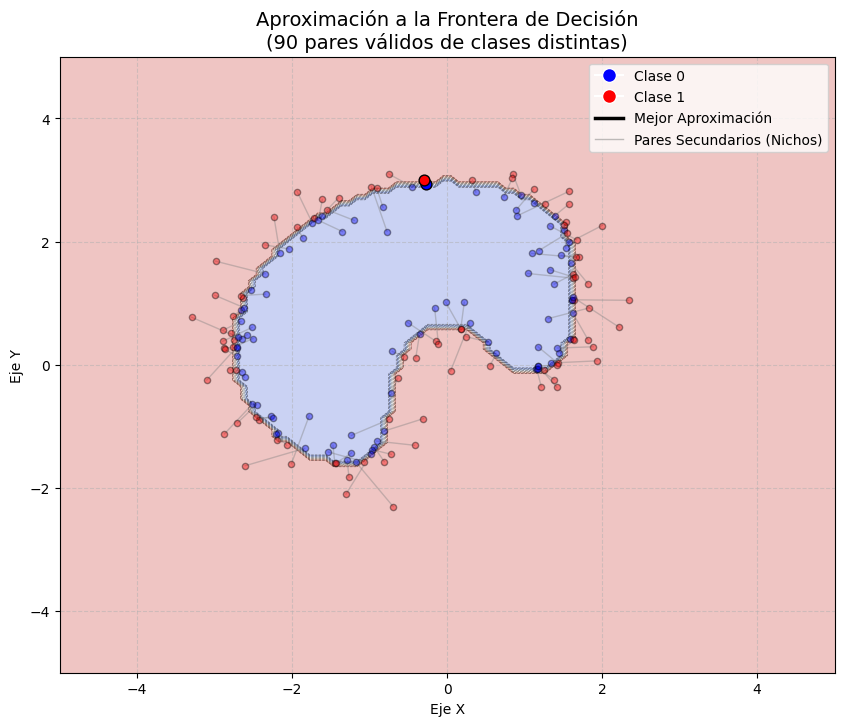

  --- Métrica: Manhattan ---
Mejor par -> P1: (1.02, 2.74) [clase 0], P2: (1.04, 2.74) [clase 1] | Fitness: 0.2053


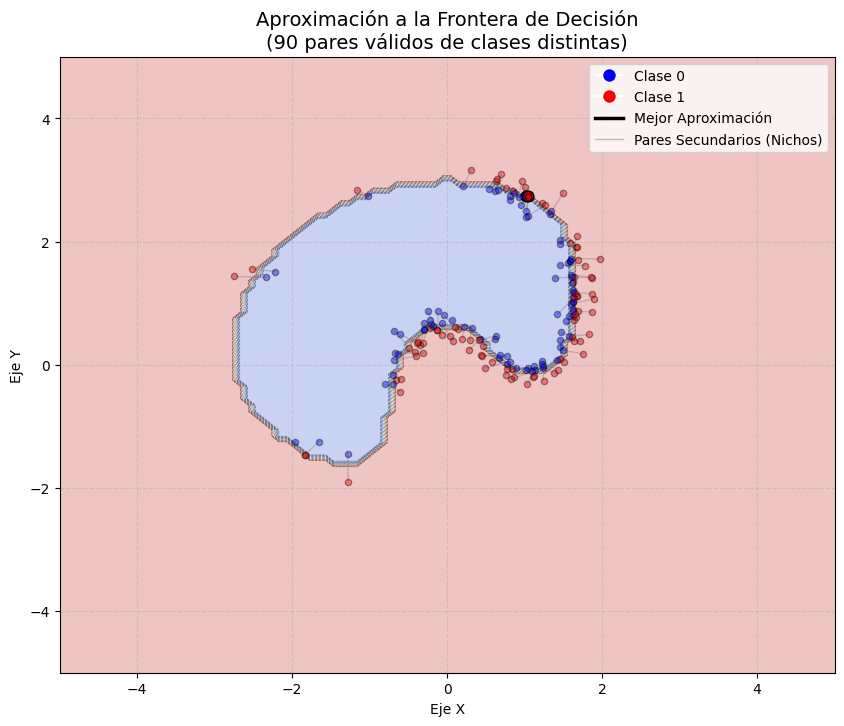

  --- Métrica: Chebyshev ---
Mejor par -> P1: (1.65, 1.08) [clase 1], P2: (1.63, 1.05) [clase 0] | Fitness: 0.1913


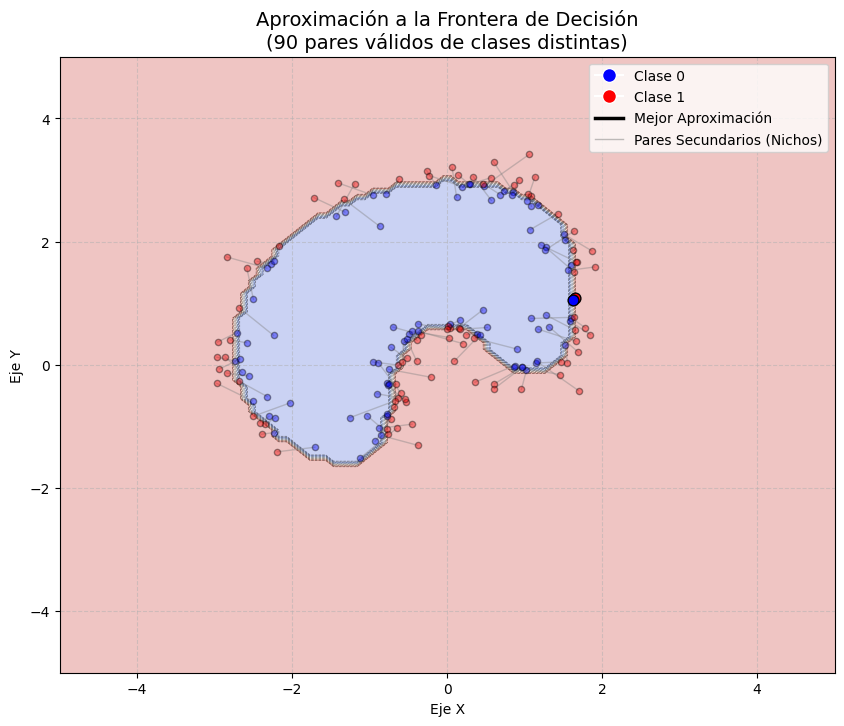

---------------------------------------------

▶ MODELO: Modelo_B
---------------------------------------------
  --- Métrica: Euclidea ---
Mejor par -> P1: (-0.12, -0.59) [clase 1], P2: (-0.11, -0.60) [clase 0] | Fitness: 0.1346


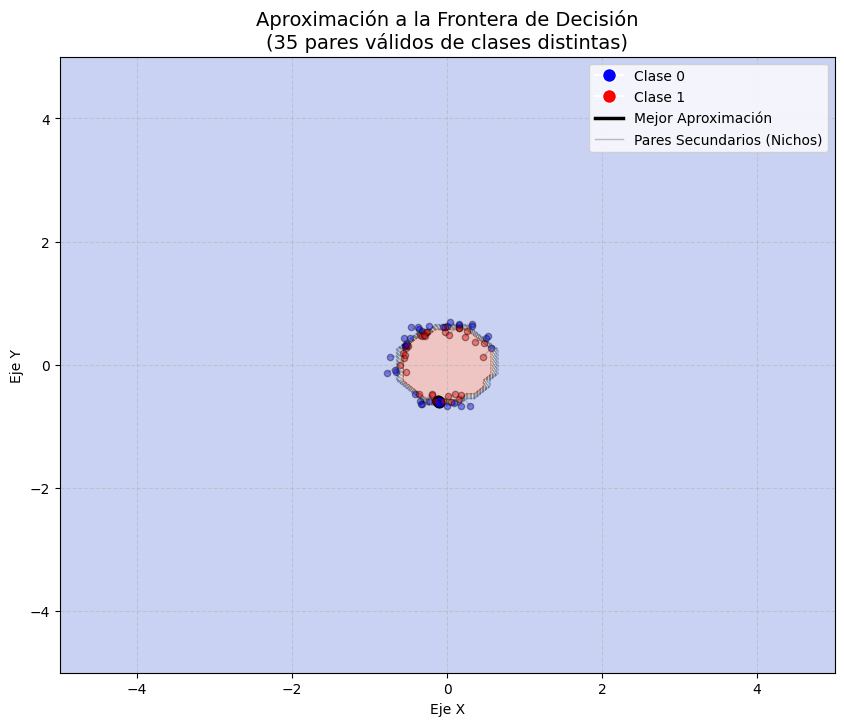

  --- Métrica: Manhattan ---
Mejor par -> P1: (-0.48, 0.39) [clase 0], P2: (-0.49, 0.36) [clase 1] | Fitness: 0.2120


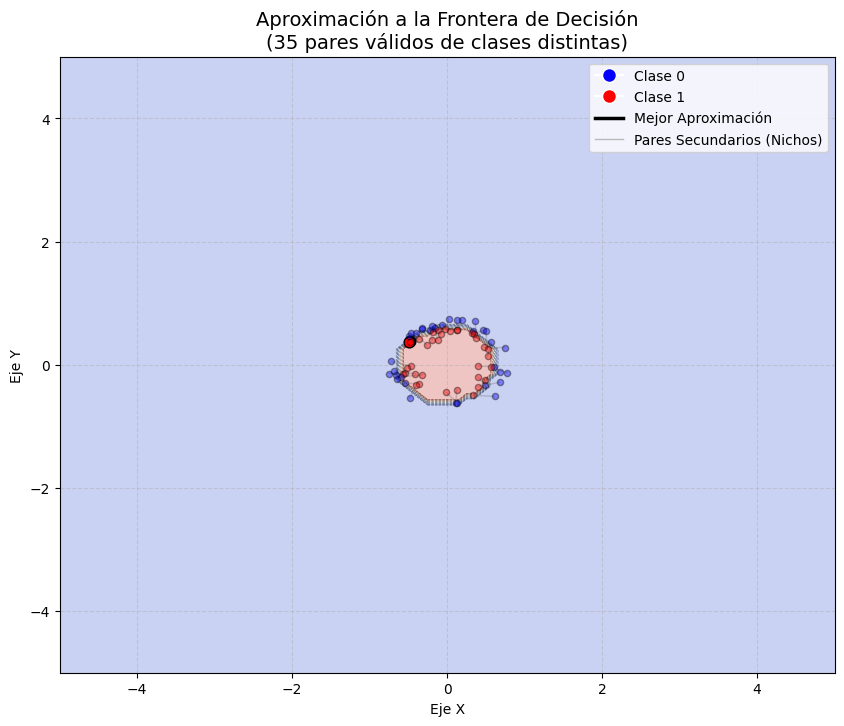

  --- Métrica: Chebyshev ---
Mejor par -> P1: (-0.01, 0.60) [clase 1], P2: (-0.01, 0.63) [clase 0] | Fitness: 0.1884


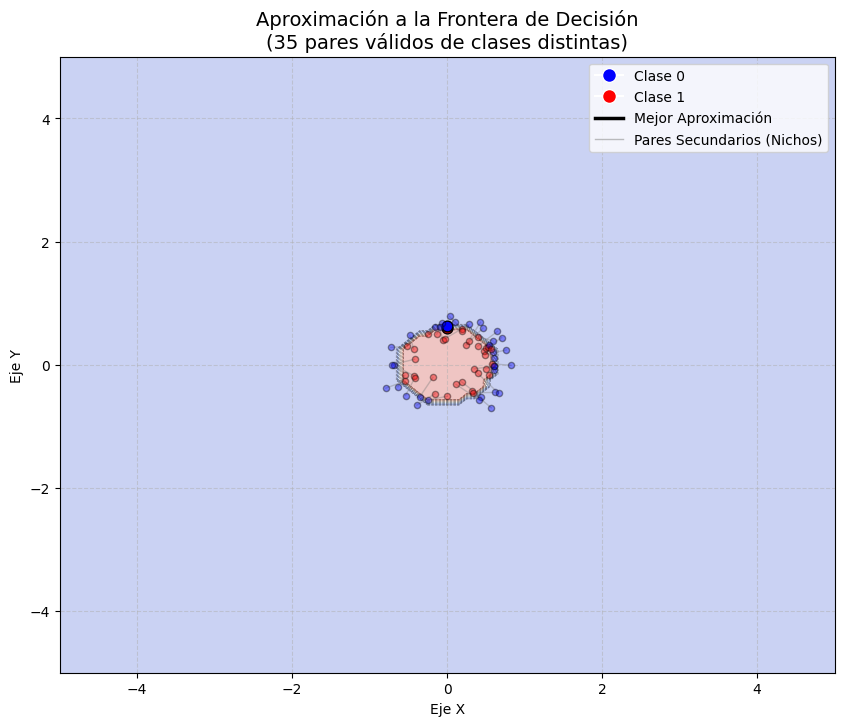

---------------------------------------------


In [ ]:
# Recorremos el diccionario principal directamente por modelo
for modelo_nombre, metricas_data in resultados_totales.items():
    print(f"\n▶ MODELO: {modelo_nombre}")
    print("-" * 45)

    # 1. Recuperamos el objeto real del modelo usando el diccionario 'models'
    # Esto es vital para que la gráfica pueda hacer las predicciones del fondo
    modelo_caja_negra = models[modelo_nombre]

    # Iteramos sobre cada métrica para obtener la élite correspondiente
    for nombre_distancia, resultados_metricos in metricas_data.items():
        print(f"  --- Métrica: {nombre_distancia} ---")
        # Extraemos la élite devuelta por el experimento
        elite = resultados_metricos['elite']

        # Llamamos a nuestra función de graficación para mostrar la dispersión entre puntos
        plot_resultados(
            bb_model=modelo_caja_negra,
            elite=elite,
            limites=(-5.0, 5.0),
        )

    print("-" * 45)

###Resultados RS



Mismas visualizaciones que el GA (scatter sobre frontera + convergencia best-so-far) para el Random Search, permitiendo comparación visual directa entre ambos métodos.

In [ ]:
def plot_resultados_rs(resultados_rs, models_dict, limites=(-5.0, 5.0)):
    """
    Para cada modelo dibuja un panel 2x2:
      · Convergencia (best-so-far) de las 3 métricas de distancia.
      · Tres scatter con el contorno del modelo (frontera real) y la élite
        final por métrica (mejor par destacado en negro).

    Replica visualmente a `plot_resultados` del GA para que la comparación
    sea directa.
    """
    min_val, max_val = limites
    colores_metrica = {
        "Euclidea":  "tab:blue",
        "Manhattan": "tab:green",
        "Chebyshev": "tab:orange",
    }

    for nombre_modelo, metricas in resultados_rs.items():
        caja_negra = models_dict[nombre_modelo]

        # Malla de fondo (predicción vectorizada, igual que en plot_resultados)
        xx, yy = np.meshgrid(np.linspace(min_val, max_val, 100),
                             np.linspace(min_val, max_val, 100))
        Z = caja_negra.model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        fig, axs = plt.subplots(2, 2, figsize=(16, 14))
        fig.suptitle(f"Random Search · {nombre_modelo}",
                     fontsize=18, fontweight='bold', y=0.98)

        # ─── Panel 1: convergencia ───
        ax_conv = axs[0, 0]
        ax_conv.set_title("Evolución del mejor fitness (best-so-far)", fontsize=14)
        ax_conv.set_xlabel("Iteración")
        ax_conv.set_ylabel("Fitness (minimización)")
        ax_conv.grid(True, linestyle='--', alpha=0.6)
        for nombre_distancia, datos in metricas.items():
            ax_conv.plot(datos["historial"],
                         label=nombre_distancia,
                         color=colores_metrica[nombre_distancia],
                         linewidth=2)
        ax_conv.legend()

        # ─── Paneles 2-4: scatter de élite con frontera ───
        mapa = {"Euclidea": axs[0, 1], "Manhattan": axs[1, 0], "Chebyshev": axs[1, 1]}

        for nombre_distancia, ax in mapa.items():
            elite = metricas[nombre_distancia]["elite"]
            ax.set_title(f"Élite final · {nombre_distancia}", fontsize=14)
            ax.set_xlim(min_val, max_val); ax.set_ylim(min_val, max_val)
            ax.grid(True, linestyle='--', alpha=0.3)

            # Frontera de decisión real
            ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
            ax.contour (xx, yy, Z, colors='k', linewidths=0.5, alpha=0.5, linestyles='--')

            if not elite:
                ax.text(0.5, 0.5, "Sin individuos válidos",
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=12, color='gray')
                continue

            # Predicciones cacheadas
            p1_arr = np.array([(ind.x1, ind.y1) for ind in elite])
            p2_arr = np.array([(ind.x2, ind.y2) for ind in elite])
            c1s = caja_negra.model.predict(p1_arr)
            c2s = caja_negra.model.predict(p2_arr)
            clases_unicas = sorted(np.unique(np.concatenate([c1s, c2s])), key=int)
            if len(clases_unicas) >= 2:
                color_clase = {int(clases_unicas[0]): 'blue',
                               int(clases_unicas[1]): 'red'}
            else:
                color_clase = {int(clases_unicas[0]): 'blue'}

            # Mejor par primero (destacado), el resto en gris translúcido
            orden = sorted(range(len(elite)), key=lambda i: elite[i].fitness)
            for rank, i in enumerate(orden):
                ind = elite[i]
                c1, c2 = int(c1s[i]), int(c2s[i])
                es_mejor = (rank == 0)
                lw  = 2.5 if es_mejor else 1.0
                alp = 1.0 if es_mejor else 0.4
                col = 'black' if es_mejor else 'gray'
                s   = 60 if es_mejor else 20
                ax.plot([ind.x1, ind.x2], [ind.y1, ind.y2],
                        color=col, alpha=alp, linewidth=lw, zorder=5)
                ax.scatter(ind.x1, ind.y1, color=color_clase.get(c1, 'purple'),
                           s=s, edgecolor='black', alpha=alp, zorder=10)
                ax.scatter(ind.x2, ind.y2, color=color_clase.get(c2, 'purple'),
                           s=s, edgecolor='black', alpha=alp, zorder=10)

            leyenda = [
                Line2D([0], [0], marker='o', color='w',
                       label=f"Clase {int(clases_unicas[0])}",
                       markerfacecolor='blue', markersize=10),
                Line2D([0], [0], color='black', lw=2.5,
                       label='Mejor par'),
                Line2D([0], [0], color='gray', lw=1, alpha=0.5,
                       label='Pares secundarios'),
            ]
            if len(clases_unicas) >= 2:
                leyenda.insert(1, Line2D([0], [0], marker='o', color='w',
                                         label=f"Clase {int(clases_unicas[1])}",
                                         markerfacecolor='red', markersize=10))
            ax.legend(handles=leyenda, loc='upper right', fontsize=9)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


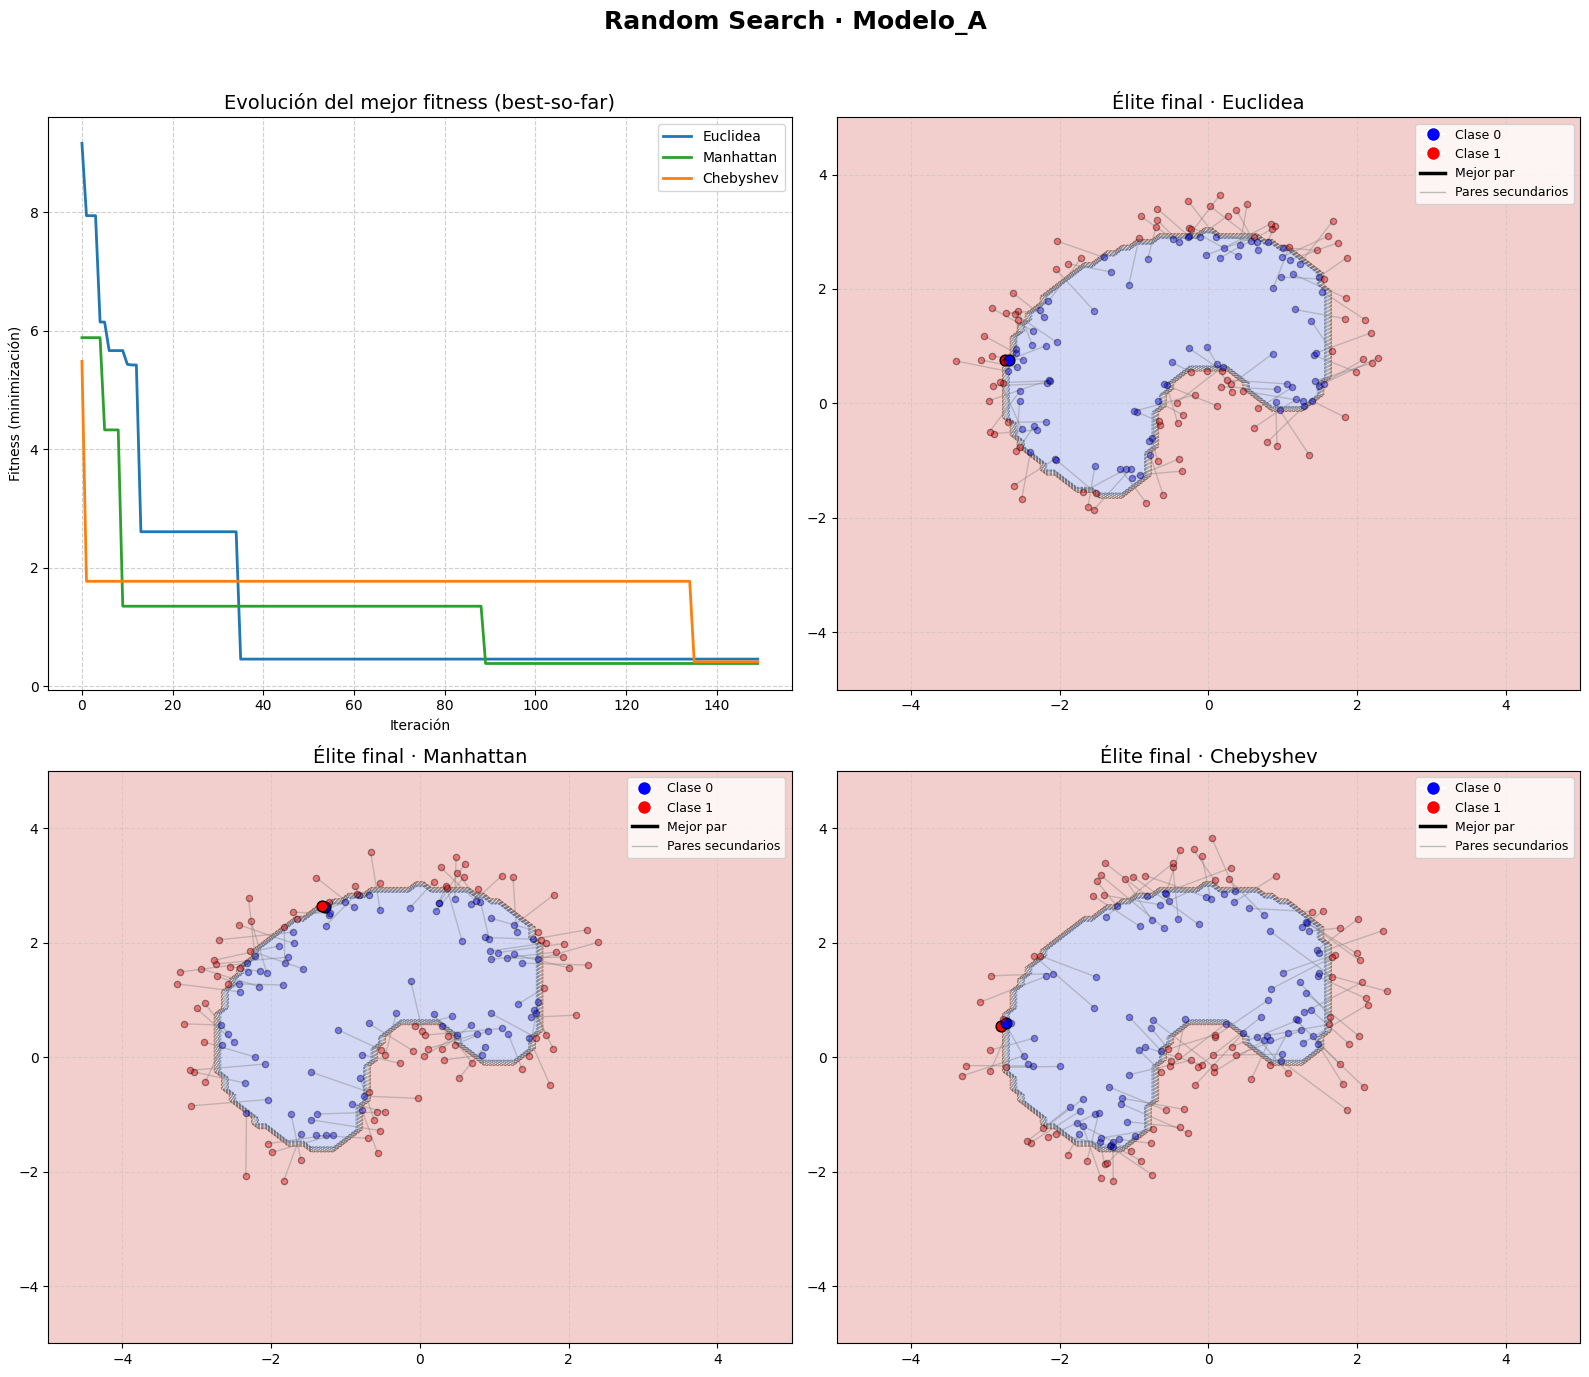

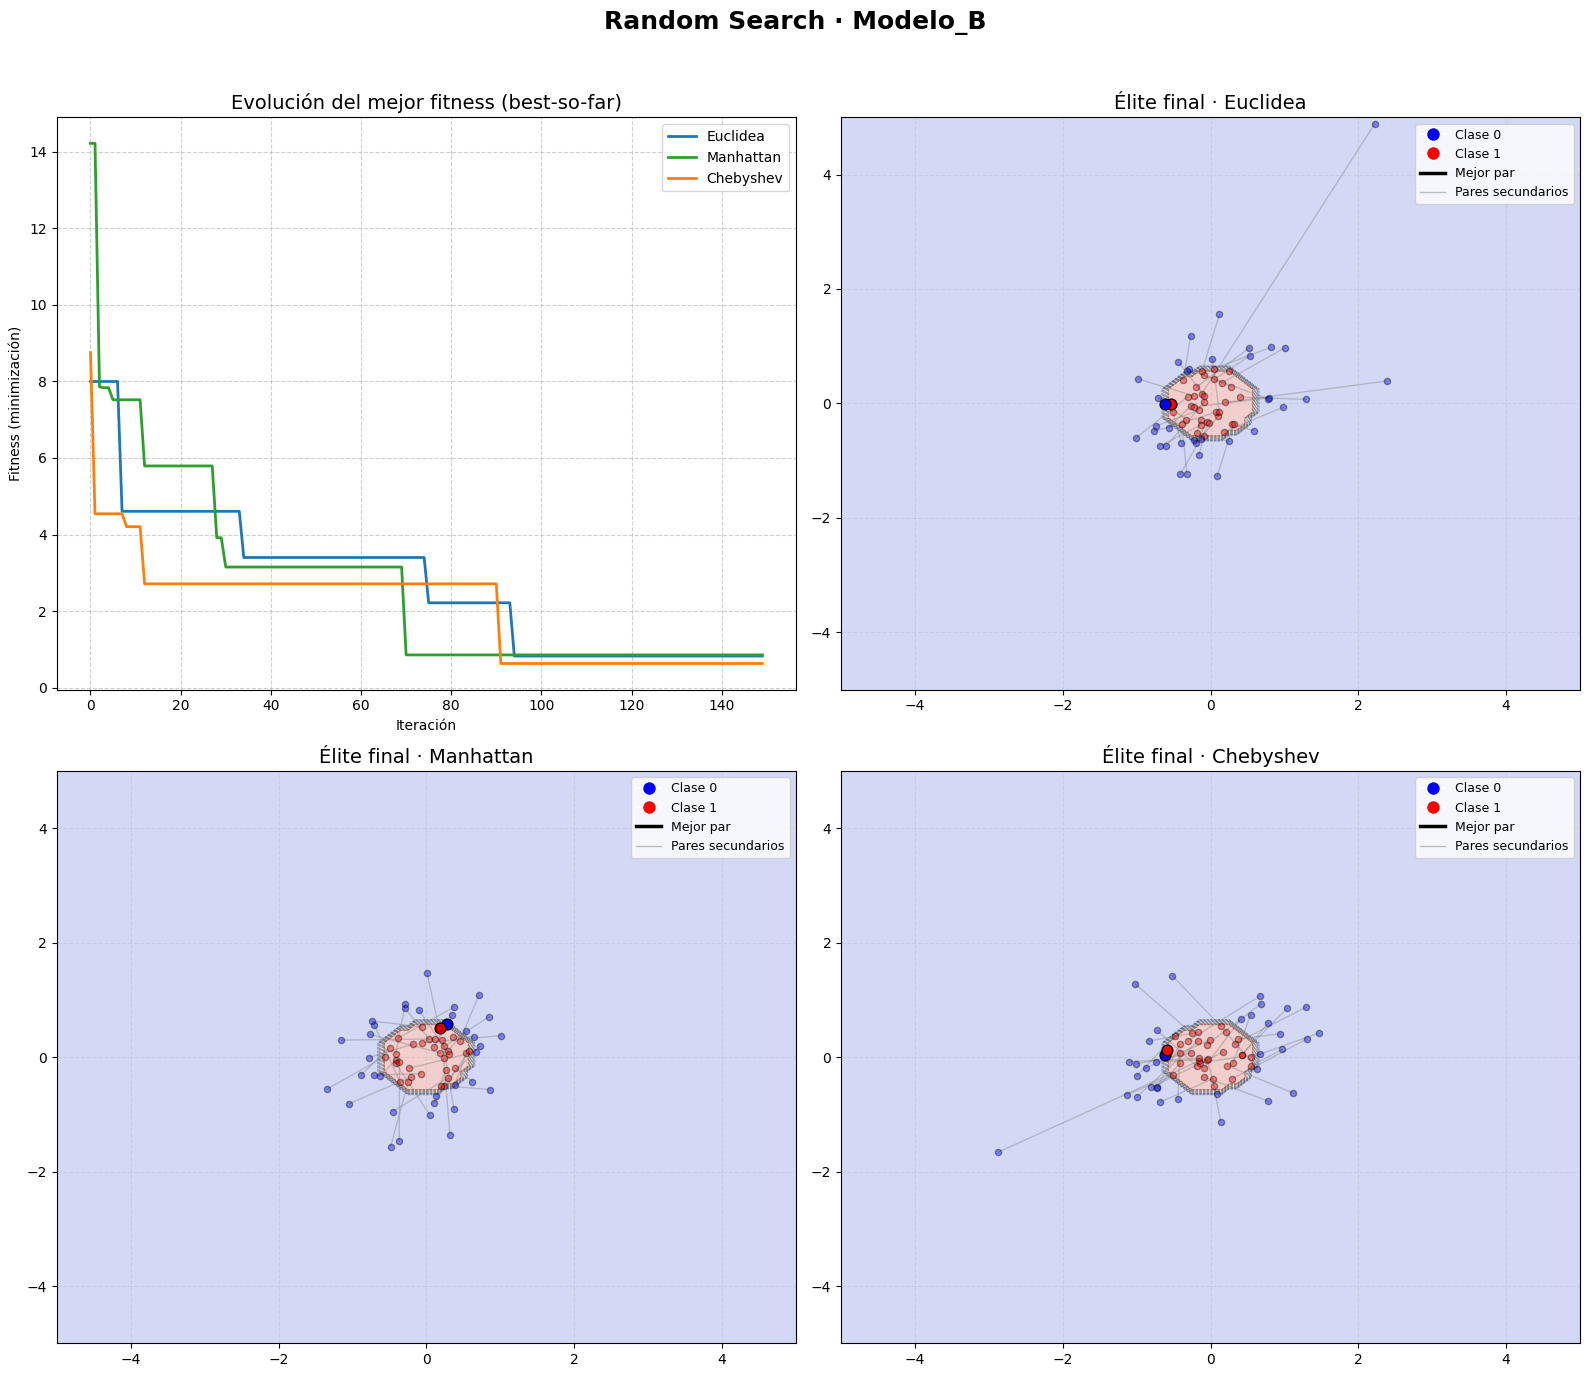

In [ ]:
plot_resultados_rs(resultados_azar, models)

###Comparativa AG vs RS

Comparación del GA frente al RS bajo idéntico presupuesto de evaluaciones. Se presentan curvas de convergencia por (modelo, métrica), boxplots de las métricas objetivas sobre todas las runs, y tablas de estadísticos descriptivos con indicación del ganador por combinación.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL DE LA COMPARATIVA
# ─────────────────────────────────────────────────────────────
# Dirección de mejora por métrica objetiva. Usada por todas las
# funciones de esta sección y de Análisis Estadístico para decidir
# quién gana en cada celda y para etiquetar las gráficas.
METRICAS_OBJETIVO = {
    'dist_media'      : ('↓', 'Distancia media del par'),
    'cobertura'       : ('↑', 'Cobertura del elite'),
    'dispersion_media': ('↑', 'Dispersión media puntos medios'),
    'dispersion_min'  : ('↑', 'Dispersión mínima'),
}


def _es_mejor(val_ga, val_rs, direccion):
    """Devuelve 'GA', 'RS' o 'Empate' según la dirección de la métrica."""
    if np.isnan(val_ga) or np.isnan(val_rs):
        return "—"
    if val_ga == val_rs:
        return "Empate"
    if direccion == '↑':
        return "GA" if val_ga > val_rs else "RS"
    return "GA" if val_ga < val_rs else "RS"   # ↓

In [ ]:
# ─────────────────────────────────────────────────────────────
# HELPERS COMPARTIDOS (extracción de métricas + best-so-far)
# ─────────────────────────────────────────────────────────────

def _extraer_metricas_elite(elite, distance_func, elite_size_esperado):
    """
    Dado un elite, devuelve un dict con las métricas objetivas del problema:
      · n_validos        : pares con clases distintas
      · cobertura        : n_validos / elite_size_esperado (0–1)
      · dist_media       : distancia media de los pares válidos
      · dist_mediana     : mediana de distancias
      · dist_p10 / p90   : percentiles
      · dispersion_media : distancia media entre puntos medios del elite
      · dispersion_min   : distancia mínima entre puntos medios (crowding)
    """
    validos = [ind for ind in elite if ind.is_valid]
    if not validos:
        return {k: np.nan for k in [
            'n_validos', 'cobertura', 'dist_media', 'dist_mediana',
            'dist_p10', 'dist_p90', 'dispersion_media', 'dispersion_min'
        ]}

    dists = np.array([
        distance_func((ind.x1, ind.y1), (ind.x2, ind.y2))
        for ind in validos
    ])
    mid = np.array([((ind.x1 + ind.x2) / 2, (ind.y1 + ind.y2) / 2)
                    for ind in validos])

    if len(mid) >= 2:
        # pdist en C: ~50× más rápido que doble bucle Python
        pares_mid = pdist(mid)
        disp_media = float(np.mean(pares_mid))
        disp_min   = float(np.min(pares_mid))
    else:
        disp_media = disp_min = np.nan

    return {
        'n_validos'       : len(validos),
        'cobertura'       : len(validos) / elite_size_esperado,
        'dist_media'      : float(np.mean(dists)),
        'dist_mediana'    : float(np.median(dists)),
        'dist_p10'        : float(np.percentile(dists, 10)),
        'dist_p90'        : float(np.percentile(dists, 90)),
        'dispersion_media': disp_media,
        'dispersion_min'  : disp_min,
    }

In [ ]:
# ─────────────────────────────────────────────────────────────
# TABLA 1 — Estadísticos por métrica objetiva (todas las runs)
# Necesaria para la memoria: demuestra robustez, no solo el mejor caso
# ─────────────────────────────────────────────────────────────

def tabla_estadisticos_runs(resultados_ga, resultados_rs,
                             metricas_distancia_dict, models_dict):
    """
    Para cada (modelo, métrica_distancia, algoritmo) y para cada
    métrica objetiva del problema devuelve: media ± std, mediana,
    min y max sobre todas las runs.

    Esta tabla va en la sección 'Resultados experimentales' de la memoria.
    """
    metricas  = list(metricas_distancia_dict.keys())
    modelos   = list(models_dict.keys())

    filas = []
    for modelo in modelos:
        elite_size_esp = ELITE_SIZE[modelo]
        for dist_name, dist_func in metricas_distancia_dict.items():

            for algo_name, resultados in [("GA", resultados_ga),
                                           ("RS", resultados_rs)]:
                runs = resultados[modelo][dist_name]["todas_runs"]
                # Extraemos métricas objetivas de cada run
                mets_runs = [
                    _extraer_metricas_elite(
                        r["elite"], dist_func, elite_size_esp)
                    for r in runs
                ]

                for metrica_obj in ['cobertura', 'dist_media',
                                    'dist_mediana', 'dispersion_media',
                                    'dispersion_min']:
                    vals = np.array([m[metrica_obj] for m in mets_runs
                                     if not np.isnan(m[metrica_obj])])
                    if len(vals) == 0:
                        continue
                    filas.append({
                        "Modelo"        : modelo,
                        "Distancia"     : dist_name,
                        "Algoritmo"     : algo_name,
                        "Métrica obj."  : metrica_obj,
                        "Media"         : np.mean(vals),
                        "Std"           : np.std(vals, ddof=1) if len(vals)>1 else np.nan,
                        "Mediana"       : np.median(vals),
                        "Min"           : np.min(vals),
                        "Max"           : np.max(vals),
                        "N runs"        : len(vals),
                    })

    df = pd.DataFrame(filas)
    # Formato legible
    for col in ["Media","Std","Mediana","Min","Max"]:
        df[col] = df[col].map(lambda x: f"{x:.4f}" if not np.isnan(x) else "—")
    return df

def _historial_best_so_far(historial_ga_raw):
    """
    Convierte el historial generación-a-generación del GA
    (lista de listas de fitness) en best-so-far acumulado,
    igual que ya hace el RS. Necesario para comparar curvas
    en la misma escala semántica.
    """
    best = np.inf
    bsf = []
    for gen in historial_ga_raw:
        if gen:
            best = min(best, min(gen))
        bsf.append(best)
    return bsf

In [ ]:
# ─────────────────────────────────────────────────────────────
# GRÁFICA 1 — Curvas de convergencia best-so-far
# ─────────────────────────────────────────────────────────────

def plot_convergencia_bsf(resultados_ga, resultados_rs,
                          metricas_distancia_dict, models_dict):
    """
    Curvas best-so-far con banda de ± 1 std sobre todas las runs.
    Ambos algoritmos se plotean en la misma escala semántica:
      · eje X = evaluaciones acumuladas / pop_size (generación equivalente)
      · eje Y = mejor fitness acumulado hasta ese punto

    La banda de std es clave en la memoria: muestra variabilidad,
    no solo la mejor run.
    """
    metricas = list(metricas_distancia_dict.keys())
    modelos  = list(models_dict.keys())

    fig, axs = plt.subplots(len(modelos), len(metricas),
                            figsize=(6*len(metricas), 5*len(modelos)),
                            squeeze=False)
    fig.suptitle("Convergencia best-so-far: GA vs RS  (media ± std sobre runs)",
                 fontsize=15, fontweight='bold', y=1.01)

    for i, modelo in enumerate(modelos):
        for j, dist_name in enumerate(metricas):
            ax = axs[i][j]

            for algo_name, resultados, color, ls in [
                ("GA", resultados_ga, 'tab:red',  '-'),
                ("RS", resultados_rs, 'tab:gray', '--'),
            ]:
                runs = resultados[modelo][dist_name]["todas_runs"]

                if algo_name == "GA":
                    bsf_runs = [_historial_best_so_far(r["historial"])
                                for r in runs]
                else:
                    bsf_runs = [r["historial"] for r in runs]

                # Igualar longitudes (trim al mínimo)
                min_len = min(len(b) for b in bsf_runs)
                bsf_arr = np.array([b[:min_len] for b in bsf_runs])

                media = bsf_arr.mean(axis=0)
                std   = (bsf_arr.std(axis=0, ddof=1)
                         if len(bsf_arr) > 1 else np.zeros(min_len))
                xs = np.arange(min_len)

                ax.plot(xs, media, label=algo_name, color=color,
                        linewidth=2, linestyle=ls)
                ax.fill_between(xs, media - std, media + std,
                                color=color, alpha=0.15)

            ax.set_title(f"{modelo} · {dist_name}", fontsize=12)
            ax.set_xlabel("Generación / Iteración equivalente")
            ax.set_ylabel("Best-so-far fitness (↓ mejor)")
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# GRÁFICA 2 — Boxplots por métrica objetiva
# ─────────────────────────────────────────────────────────────

def plot_boxplots_metricas(resultados_ga, resultados_rs,
                           metricas_distancia_dict, models_dict,
                           elite_size_dict):
    """
    Para cada modelo: una figura con subplots por métrica objetiva.
    Cada subplot tiene un boxplot GA vs RS por distancia.

    Esto permite ver dónde gana cada algoritmo: típicamente el GA gana
    en precisión (dist_media baja) y el RS en dispersión (puntos repartidos).
    """
    for modelo in models_dict:
        elite_size_esp = elite_size_dict[modelo]
        fig, axs = plt.subplots(1, len(METRICAS_OBJETIVO),
                                figsize=(6*len(METRICAS_OBJETIVO), 5),
                                squeeze=False)
        fig.suptitle(f"Distribución de métricas objetivas — {modelo}",
                     fontsize=14, fontweight='bold')

        for k, (met, (direccion, label_base)) in enumerate(METRICAS_OBJETIVO.items()):
            ax = axs[0][k]
            data_ga, data_rs, labels = [], [], []

            for dist_name, dist_func in metricas_distancia_dict.items():
                runs_ga = resultados_ga[modelo][dist_name]["todas_runs"]
                runs_rs = resultados_rs[modelo][dist_name]["todas_runs"]

                vals_ga = [_extraer_metricas_elite(r["elite"], dist_func,
                           elite_size_esp)[met] for r in runs_ga]
                vals_rs = [_extraer_metricas_elite(r["elite"], dist_func,
                           elite_size_esp)[met] for r in runs_rs]

                data_ga.append([v for v in vals_ga if not np.isnan(v)])
                data_rs.append([v for v in vals_rs if not np.isnan(v)])
                labels.append(dist_name)

            x = np.arange(len(labels))
            w = 0.3
            pos_ga = x - w/2
            pos_rs = x + w/2

            bp1 = ax.boxplot(data_ga, positions=pos_ga, widths=0.25,
                             patch_artist=True,
                             boxprops=dict(facecolor='tab:red', alpha=0.6),
                             medianprops=dict(color='darkred', linewidth=2),
                             whiskerprops=dict(color='tab:red'),
                             capprops=dict(color='tab:red'),
                             flierprops=dict(marker='o', color='tab:red',
                                             alpha=0.5))
            bp2 = ax.boxplot(data_rs, positions=pos_rs, widths=0.25,
                             patch_artist=True,
                             boxprops=dict(facecolor='tab:gray', alpha=0.6),
                             medianprops=dict(color='black', linewidth=2),
                             whiskerprops=dict(color='tab:gray'),
                             capprops=dict(color='tab:gray'),
                             flierprops=dict(marker='o', color='tab:gray',
                                             alpha=0.5))

            ax.set_xticks(x)
            ax.set_xticklabels(labels, fontsize=10)
            ax.set_title(f"{label_base} ({direccion} mejor)", fontsize=11)
            ax.set_ylabel(met)
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
            ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["GA", "RS"],
                      fontsize=10)

        plt.tight_layout()
        plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# GRÁFICA 3 — Heatmap de ganador por celda (modelo × distancia × métrica)
# Añadido propuesto: una mirada de un solo vistazo a "quién gana dónde"
# ─────────────────────────────────────────────────────────────

def plot_heatmap_ganador(resultados_ga, resultados_rs,
                         metricas_distancia_dict, models_dict,
                         elite_size_dict):
    """
    Heatmap categórico: filas = (modelo × distancia), columnas = métrica objetiva.
    Cada celda se colorea según quién gana en mediana sobre todas las runs.
    Permite ver en un golpe de vista el patrón global de victorias.
    """
    filas_idx, matriz = [], []
    cols = list(METRICAS_OBJETIVO.keys())

    for modelo in models_dict:
        elite_size_esp = elite_size_dict[modelo]
        for dist_name, dist_func in metricas_distancia_dict.items():
            try:
                runs_ga = resultados_ga[modelo][dist_name]["todas_runs"]
                runs_rs = resultados_rs[modelo][dist_name]["todas_runs"]
            except KeyError:
                continue

            mets_ga = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_ga]
            mets_rs = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_rs]

            fila = []
            for met in cols:
                direccion = METRICAS_OBJETIVO[met][0]
                vg = np.array([m[met] for m in mets_ga if not np.isnan(m[met])])
                vr = np.array([m[met] for m in mets_rs if not np.isnan(m[met])])
                if len(vg) == 0 or len(vr) == 0:
                    fila.append(0)  # — sin datos
                    continue
                ganador = _es_mejor(np.median(vg), np.median(vr), direccion)
                # Codificación numérica:  GA=+1, RS=-1, Empate/—=0
                fila.append({"GA": 1, "RS": -1}.get(ganador, 0))
            matriz.append(fila)
            filas_idx.append(f"{modelo} · {dist_name}")

    matriz = np.array(matriz, dtype=float)

    fig, ax = plt.subplots(figsize=(2.2*len(cols) + 2, 0.6*len(filas_idx) + 2))
    cmap = plt.cm.RdYlGn   # rojo = RS gana, verde = GA gana
    im = ax.imshow(matriz, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels([f"{m}\n({METRICAS_OBJETIVO[m][0]} mejor)" for m in cols],
                       fontsize=10)
    ax.set_yticks(np.arange(len(filas_idx)))
    ax.set_yticklabels(filas_idx, fontsize=10)

    # Anotación textual en cada celda
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            valor = matriz[i, j]
            txt = "GA" if valor > 0 else ("RS" if valor < 0 else "—")
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='black' if abs(valor) < 1 else 'white')

    ax.set_title("¿Quién gana en mediana? (verde=GA, rojo=RS)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# TABLA 1 — Descriptivos completos por (modelo, distancia, algoritmo, métrica)
# Tabla detallada para el anexo de la memoria
# ─────────────────────────────────────────────────────────────

def tabla_estadisticos_runs(resultados_ga, resultados_rs,
                            metricas_distancia_dict, models_dict,
                            elite_size_dict):
    """
    Tabla detallada con media ± std, mediana, min y max sobre todas las runs,
    para cada (modelo, distancia, algoritmo, métrica_objetiva).

    Va en la sección 'Resultados experimentales' de la memoria.
    """
    filas = []
    for modelo in models_dict:
        elite_size_esp = elite_size_dict[modelo]
        for dist_name, dist_func in metricas_distancia_dict.items():

            for algo_name, resultados in [("GA", resultados_ga),
                                          ("RS", resultados_rs)]:
                runs = resultados[modelo][dist_name]["todas_runs"]
                mets_runs = [_extraer_metricas_elite(r["elite"], dist_func,
                                                    elite_size_esp)
                             for r in runs]

                for metrica_obj in ['cobertura', 'dist_media', 'dist_mediana',
                                    'dispersion_media', 'dispersion_min']:
                    vals = np.array([m[metrica_obj] for m in mets_runs
                                     if not np.isnan(m[metrica_obj])])
                    if len(vals) == 0:
                        continue
                    filas.append({
                        "Modelo"       : modelo,
                        "Distancia"    : dist_name,
                        "Algoritmo"    : algo_name,
                        "Métrica obj." : metrica_obj,
                        "Media"        : np.mean(vals),
                        "Std"          : (np.std(vals, ddof=1)
                                          if len(vals) > 1 else np.nan),
                        "Mediana"      : np.median(vals),
                        "Min"          : np.min(vals),
                        "Max"          : np.max(vals),
                        "N runs"       : len(vals),
                    })

    df = pd.DataFrame(filas)
    for col in ["Media", "Std", "Mediana", "Min", "Max"]:
        df[col] = df[col].map(lambda x: f"{x:.4f}" if not np.isnan(x) else "—")
    return df

In [ ]:
# ─────────────────────────────────────────────────────────────
# TABLA 2 — Descriptivos compactos μ(σ) GA vs RS lado a lado
# Formato pensado para el cuerpo de la memoria (no el anexo)
# ─────────────────────────────────────────────────────────────

def tabla_descriptivos_compacta(resultados_ga, resultados_rs,
                                metricas_distancia_dict, models_dict,
                                elite_size_dict):
    """
    Tabla compacta con formato 'media (std)' lado a lado para GA y RS,
    con columna 'Mejor' que respeta la dirección de cada métrica.
    """
    filas = []

    for modelo in models_dict:
        elite_size_esp = elite_size_dict[modelo]

        for dist_name, dist_func in metricas_distancia_dict.items():
            try:
                runs_ga = resultados_ga[modelo][dist_name]["todas_runs"]
                runs_rs = resultados_rs[modelo][dist_name]["todas_runs"]
            except KeyError:
                continue

            mets_ga = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_ga]
            mets_rs = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_rs]

            for met, (direccion, _label) in METRICAS_OBJETIVO.items():

                vg = np.array([m[met] for m in mets_ga if not np.isnan(m[met])])
                vr = np.array([m[met] for m in mets_rs if not np.isnan(m[met])])

                def fmt(v):
                    if len(v) == 0:
                        return "—"
                    if len(v) == 1:
                        return f"{v[0]:.4f} (—)"
                    return f"{np.mean(v):.4f} ({np.std(v, ddof=1):.4f})"

                mejor = (_es_mejor(np.mean(vg), np.mean(vr), direccion)
                         if (len(vg) > 0 and len(vr) > 0) else "—")

                filas.append({
                    "Modelo"   : modelo,
                    "Distancia": dist_name,
                    "Métrica"  : f"{met} {direccion}",
                    "GA  μ(σ)" : fmt(vg),
                    "RS  μ(σ)" : fmt(vr),
                    "Mejor"    : mejor,
                    "N runs"   : min(len(vg), len(vr)),
                })

    return pd.DataFrame(filas)

In [ ]:
# ─────────────────────────────────────────────────────────────
# TABLA 3 — Resumen agregado de victorias por algoritmo
# Útil para abrir/cerrar la discusión en la memoria
# ─────────────────────────────────────────────────────────────

def tabla_resumen_ganador(resultados_ga, resultados_rs,
                          metricas_distancia_dict, models_dict,
                          elite_size_dict):
    """
    Cuenta de victorias en mediana por (algoritmo, métrica objetiva)
    agregado sobre las 6 combinaciones (modelo × distancia).

    Una vista de pájaro para responder de un golpe:
      «¿Quién gana globalmente en cada métrica?»
    """
    conteo = {met: {"GA": 0, "RS": 0, "Empate": 0}
              for met in METRICAS_OBJETIVO}

    for modelo in models_dict:
        elite_size_esp = elite_size_dict[modelo]
        for dist_name, dist_func in metricas_distancia_dict.items():
            try:
                runs_ga = resultados_ga[modelo][dist_name]["todas_runs"]
                runs_rs = resultados_rs[modelo][dist_name]["todas_runs"]
            except KeyError:
                continue

            mets_ga = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_ga]
            mets_rs = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_rs]

            for met, (direccion, _) in METRICAS_OBJETIVO.items():
                vg = np.array([m[met] for m in mets_ga if not np.isnan(m[met])])
                vr = np.array([m[met] for m in mets_rs if not np.isnan(m[met])])
                if len(vg) == 0 or len(vr) == 0:
                    continue
                g = _es_mejor(np.median(vg), np.median(vr), direccion)
                if g in conteo[met]:
                    conteo[met][g] += 1

    filas = []
    total_combinaciones = len(models_dict) * len(metricas_distancia_dict)
    for met, (direccion, label) in METRICAS_OBJETIVO.items():
        filas.append({
            "Métrica"  : f"{met} {direccion}",
            "Descripción": label,
            "GA gana"  : conteo[met]["GA"],
            "RS gana"  : conteo[met]["RS"],
            "Empate"   : conteo[met]["Empate"],
            "Total"    : total_combinaciones,
        })
    return pd.DataFrame(filas)

In [ ]:
# ─────────────────────────────────────────────────────────────
# ORQUESTADOR — Solo visual + descriptivo
# ─────────────────────────────────────────────────────────────

def mostrar_comparativa_ga_vs_rs(resultados_ga, resultados_rs,
                                 metricas_distancia_dict, models_dict,
                                 elite_size_dict):
    """
    Orquesta la parte VISUAL y DESCRIPTIVA de la comparación.
    No realiza tests estadísticos: para eso, ver `ejecutar_analisis_estadistico`.
    """
    print("\n" + "═"*60)
    print("  COMPARATIVA DESCRIPTIVA: GA vs RANDOM SEARCH")
    print("═"*60)

    print("\n[1/5] Curvas de convergencia best-so-far...")
    plot_convergencia_bsf(resultados_ga, resultados_rs,
                          metricas_distancia_dict, models_dict)

    print("\n[2/5] Boxplots por métrica objetiva...")
    plot_boxplots_metricas(resultados_ga, resultados_rs,
                           metricas_distancia_dict, models_dict,
                           elite_size_dict)

    print("\n[3/5] Heatmap de ganador por celda...")
    plot_heatmap_ganador(resultados_ga, resultados_rs,
                         metricas_distancia_dict, models_dict,
                         elite_size_dict)

    print("\n[4/5] Descriptivos compactos (media (std) GA vs RS):")
    df_desc = tabla_descriptivos_compacta(resultados_ga, resultados_rs,
                                          metricas_distancia_dict, models_dict,
                                          elite_size_dict)
    display(df_desc)

    print("\n[5/5] Resumen agregado de victorias:")
    df_resumen = tabla_resumen_ganador(resultados_ga, resultados_rs,
                                       metricas_distancia_dict, models_dict,
                                       elite_size_dict)
    display(df_resumen)

    # La tabla detallada va opcional, comentada por defecto para no saturar:
    # print("\n[Anexo] Descriptivos detallados por run:")
    # df_detalle = tabla_estadisticos_runs(resultados_ga, resultados_rs,
    #                                      metricas_distancia_dict, models_dict,
    #                                      elite_size_dict)
    # display(df_detalle)

    return df_desc, df_resumen


════════════════════════════════════════════════════════════
  COMPARATIVA DESCRIPTIVA: GA vs RANDOM SEARCH
════════════════════════════════════════════════════════════

[1/5] Curvas de convergencia best-so-far...


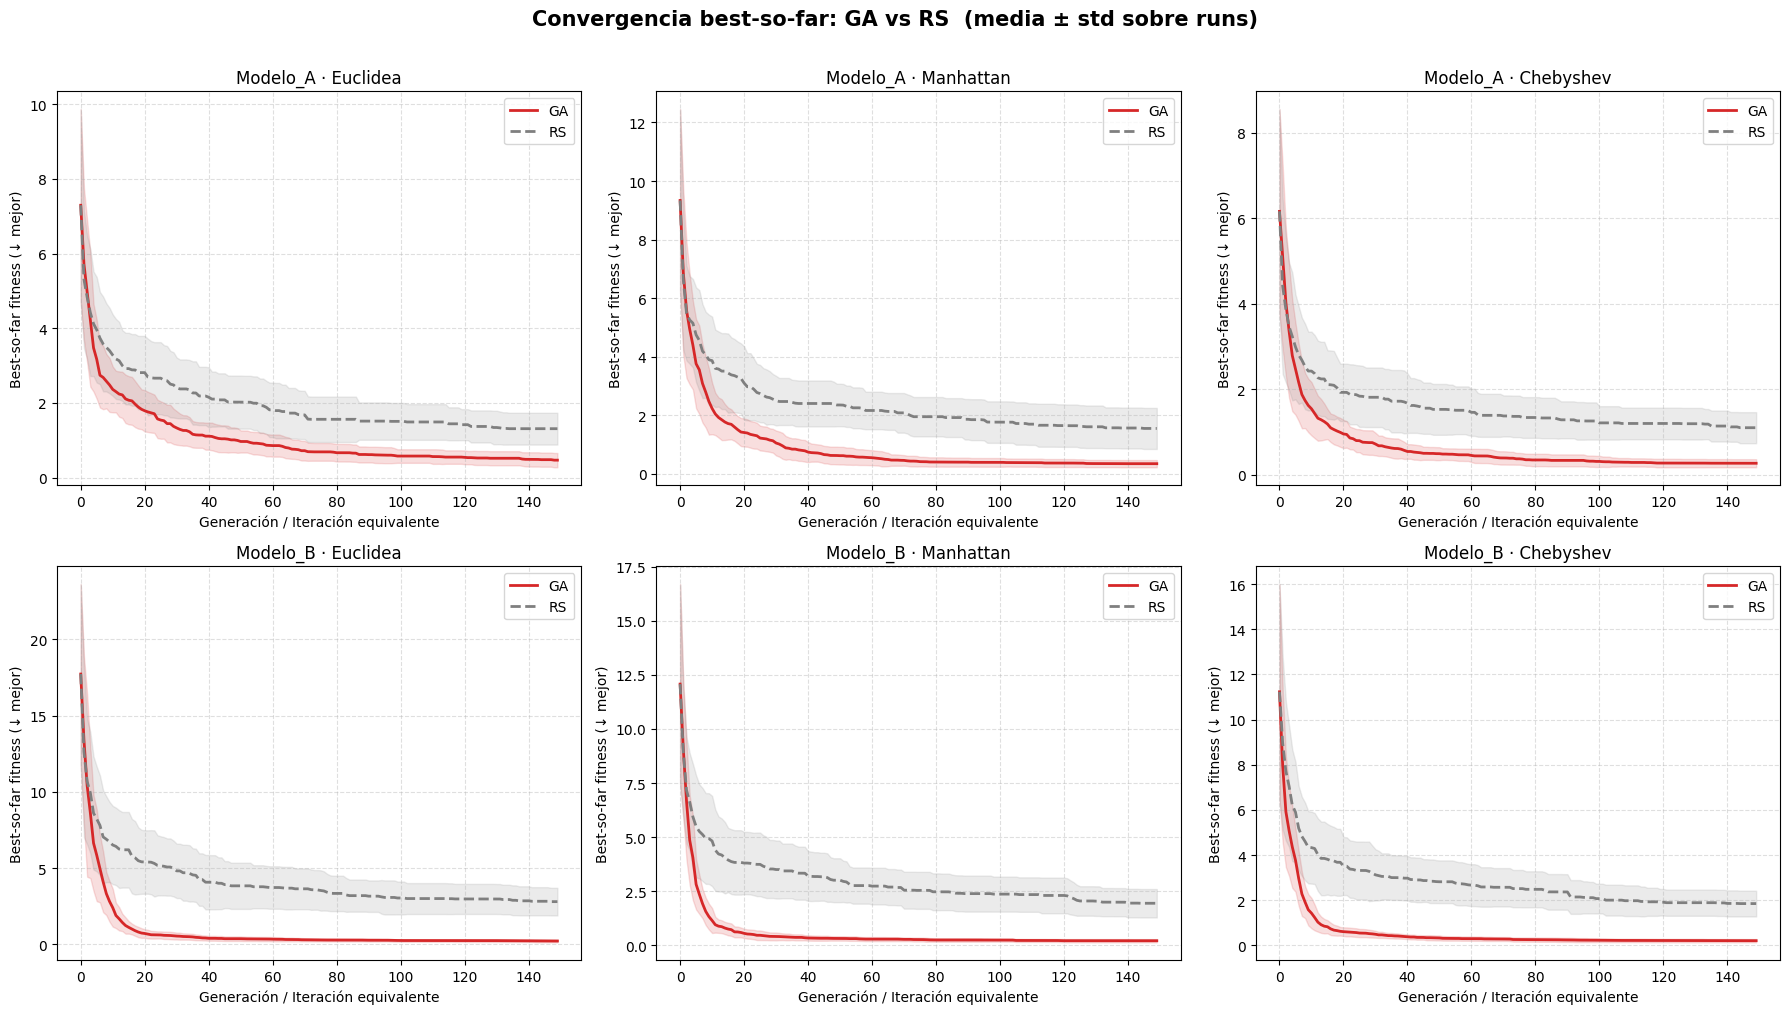


[2/5] Boxplots por métrica objetiva...


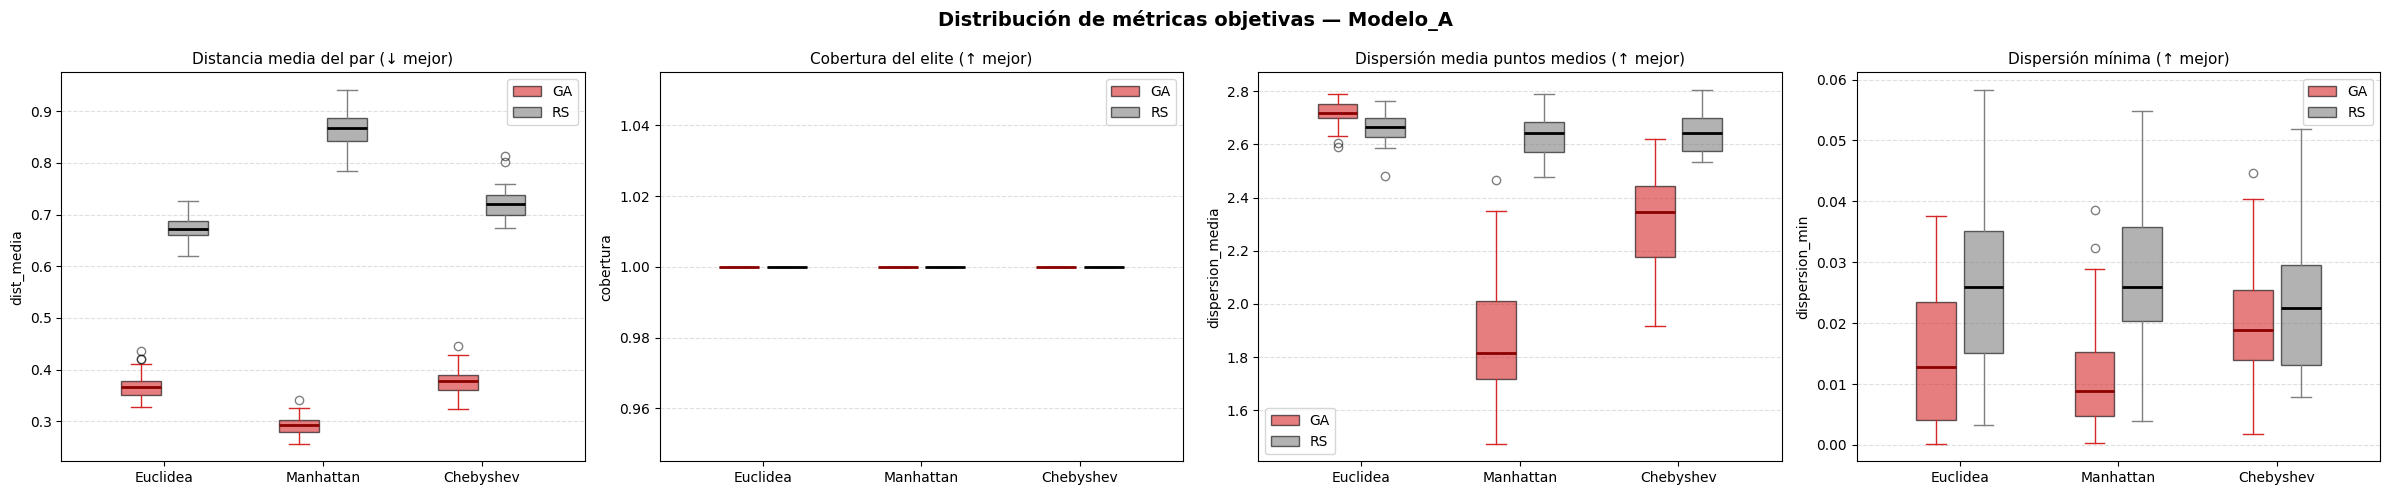

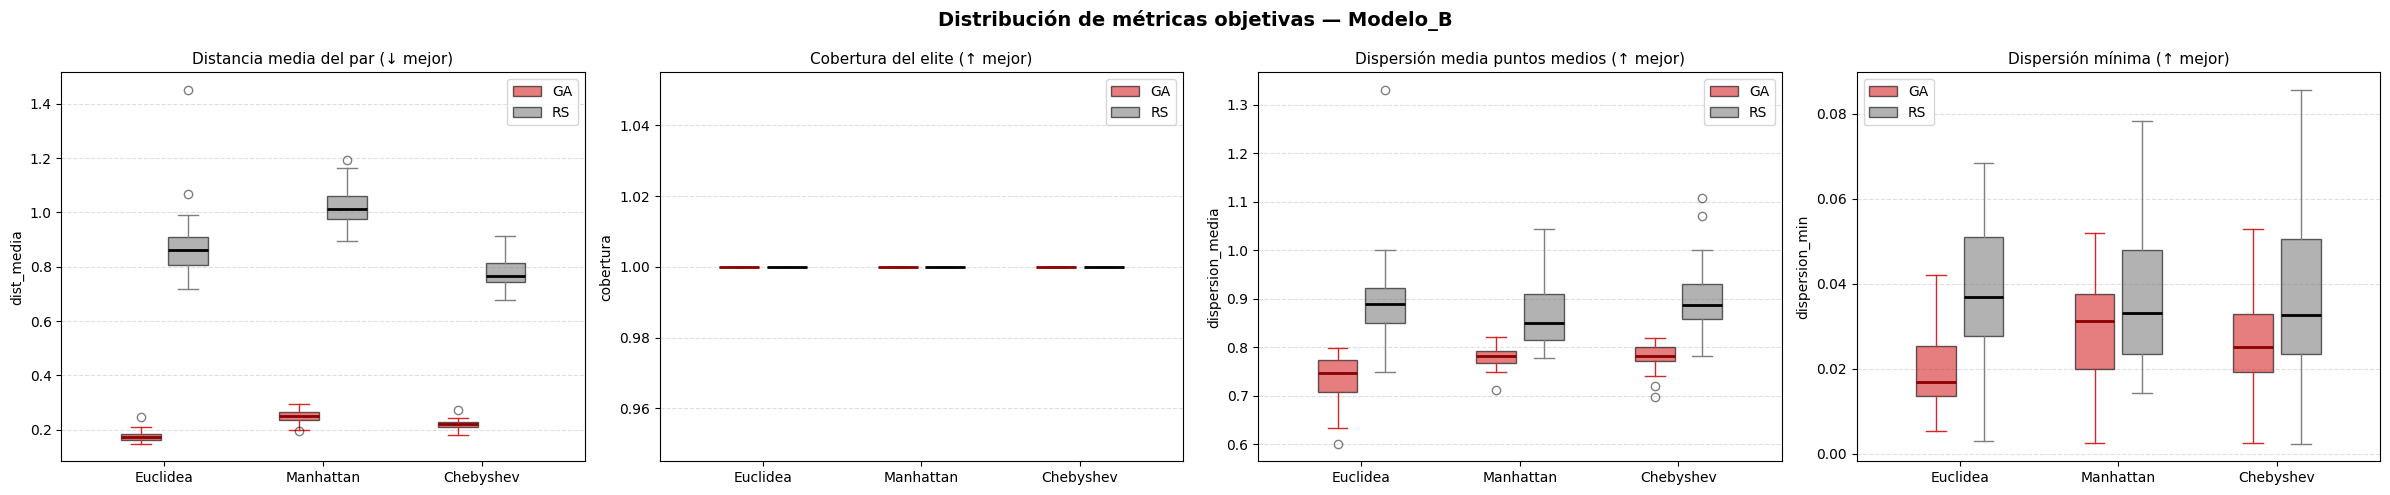


[3/5] Heatmap de ganador por celda...


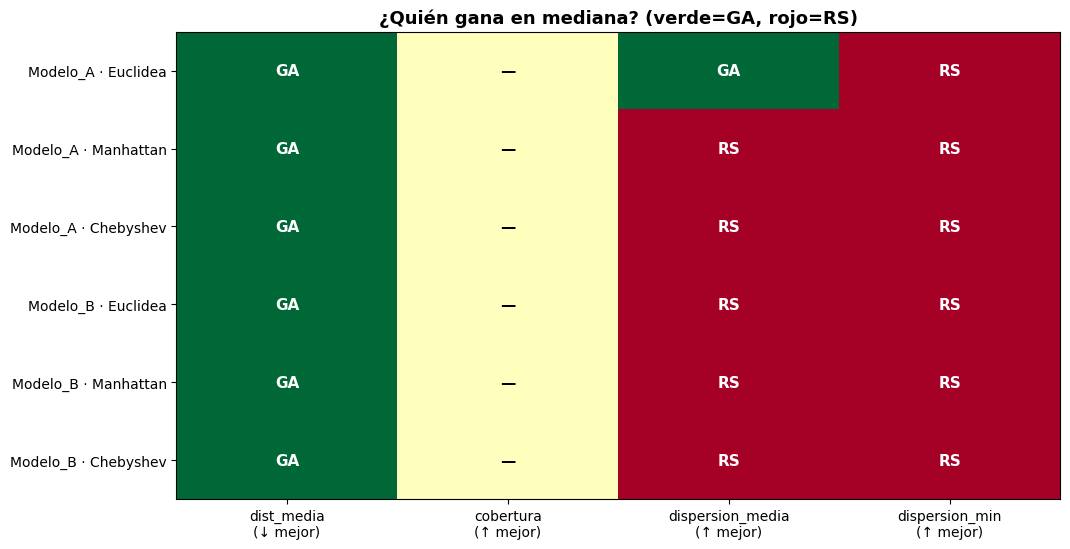


[4/5] Descriptivos compactos (media (std) GA vs RS):


,Modelo,Distancia,Métrica,GA μ(σ),RS μ(σ),Mejor,N runs
0,Modelo_A,Euclidea,dist_media ↓,0.3691 (0.0264),0.6745 (0.0230),GA,30
1,Modelo_A,Euclidea,cobertura ↑,1.0000 (0.0000),1.0000 (0.0000),Empate,30
2,Modelo_A,Euclidea,dispersion_media ↑,2.7150 (0.0490),2.6676 (0.0622),GA,30
3,Modelo_A,Euclidea,dispersion_min ↑,0.0146 (0.0118),0.0255 (0.0132),RS,30
4,Modelo_A,Manhattan,dist_media ↓,0.2937 (0.0178),0.8606 (0.0376),GA,30
5,Modelo_A,Manhattan,cobertura ↑,1.0000 (0.0000),1.0000 (0.0000),Empate,30
6,Modelo_A,Manhattan,dispersion_media ↑,1.8778 (0.2387),2.6432 (0.0807),RS,30
7,Modelo_A,Manhattan,dispersion_min ↑,0.0121 (0.0100),0.0279 (0.0119),RS,30
8,Modelo_A,Chebyshev,dist_media ↓,0.3772 (0.0272),0.7237 (0.0321),GA,30
9,Modelo_A,Chebyshev,cobertura ↑,1.0000 (0.0000),1.0000 (0.0000),Empate,30



[5/5] Resumen agregado de victorias:


,Métrica,Descripción,GA gana,RS gana,Empate,Total
0,dist_media ↓,Distancia media del par,6,0,0,6
1,cobertura ↑,Cobertura del elite,0,0,6,6
2,dispersion_media ↑,Dispersión media puntos medios,1,5,0,6
3,dispersion_min ↑,Dispersión mínima,0,6,0,6


In [ ]:
# Ejecución
df_desc, df_resumen = mostrar_comparativa_ga_vs_rs(
    resultados_ga           = resultados_totales,
    resultados_rs           = resultados_azar,
    metricas_distancia_dict = metricas_distancia,
    models_dict             = models,
    elite_size_dict         = ELITE_SIZE,
)

##Análisis Estadístico

Contraste formal de la hipótesis de que GA y RS difieren significativamente en las métricas objetivas. Primero se verifica con Shapiro-Wilk si las diferencias pareadas siguen una distribución normal (que justificaría t-test); si no, se aplica el test no paramétrico de Wilcoxon signed-rank sobre pares $(GA_i, RS_i)$ con la misma semilla. Se reporta el estadístico $W$, el $p$-valor y el effect size $|r| = |Z| / sqrt(N)$ (Rosenthal, 1991).

In [ ]:
# ─────────────────────────────────────────────────────────────
# Helper común — verificación de emparejamiento GA vs RS
# Usado por los tests pareados (Shapiro sobre diferencias, Wilcoxon).
# Si run_idx no coincide entre las dos listas, los tests pareados
# pierden validez aunque sigan corriendo.
# ─────────────────────────────────────────────────────────────
def _check_emparejamiento(runs_ga, runs_rs, n, modelo, dist_name, contexto=""):
    """
    Comprueba que las primeras `n` runs de GA y RS tengan el mismo run_idx
    en el mismo orden. Imprime WARN si no.
    Devuelve True si todo OK o si no hay forma de comprobar (campos ausentes).
    """
    idx_ga = [r.get("run_idx") for r in runs_ga[:n]]
    idx_rs = [r.get("run_idx") for r in runs_rs[:n]]
    if None in idx_ga or None in idx_rs:
        return True  # No se puede comprobar; asumimos confianza en el caller
    if idx_ga != idx_rs:
        print(f"  [WARN{(' ' + contexto) if contexto else ''}] "
              f"Emparejamiento roto en {modelo}×{dist_name}: "
              f"GA={idx_ga} vs RS={idx_rs}. Test pareado no fiable.")
        return False
    return True

In [ ]:
def tabla_normalidad_diferencias(resultados_ga, resultados_rs,
                                 metricas_distancia_dict, models_dict,
                                 elite_size_dict, alpha=0.05):
    """
    Shapiro-Wilk sobre las diferencias pareadas (GA_i - RS_i) para cada
    (modelo, distancia, métrica_objetiva).

    Interpretación:
      · p < α  → rechazamos normalidad → Wilcoxon es preferible al t-test
      · p ≥ α  → no rechazamos normalidad → ambos tests son válidos

    Para N pequeño (10–30) Shapiro-Wilk tiene poca potencia, por lo que un
    p alto NO confirma normalidad: solo dice que no hay evidencia suficiente
    para rechazarla. Aun así, su valor en la memoria es justificar
    explícitamente la elección de un test no paramétrico.
    """
    filas = []

    for modelo in models_dict:
        elite_size_esp = elite_size_dict[modelo]
        for dist_name, dist_func in metricas_distancia_dict.items():
            try:
                runs_ga = resultados_ga[modelo][dist_name]["todas_runs"]
                runs_rs = resultados_rs[modelo][dist_name]["todas_runs"]
            except KeyError:
                continue

            n = min(len(runs_ga), len(runs_rs))
            _check_emparejamiento(runs_ga, runs_rs, n, modelo, dist_name,
                                  contexto="Shapiro")
            mets_ga = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_ga[:n]]
            mets_rs = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_rs[:n]]

            for met, (direccion, _label) in METRICAS_OBJETIVO.items():
                vals_ga = np.array([m[met] for m in mets_ga])
                vals_rs = np.array([m[met] for m in mets_rs])
                mask = ~(np.isnan(vals_ga) | np.isnan(vals_rs))
                vg, vr = vals_ga[mask], vals_rs[mask]

                if len(vg) < 3:
                    # Shapiro-Wilk requiere N >= 3
                    continue

                diffs = vg - vr

                # Si todas las diferencias son iguales, Shapiro falla
                if np.all(diffs == diffs[0]):
                    filas.append({
                        "Modelo"   : modelo,
                        "Distancia": dist_name,
                        "Métrica"  : f"{met} {direccion}",
                        "N"        : int(len(diffs)),
                        "W"        : np.nan,
                        "p-valor"  : np.nan,
                        "Normal"   : "—",
                        "Test apropiado": "—",
                        "Nota"     : "Diferencias constantes",
                    })
                    continue

                try:
                    stat_w, pval = shapiro(diffs)
                    es_normal = pval >= alpha
                except Exception as exc:
                    stat_w = pval = np.nan
                    es_normal = False
                    print(f"  ⚠ Shapiro falló en {modelo}×{dist_name}×{met}: {exc}")

                filas.append({
                    "Modelo"        : modelo,
                    "Distancia"     : dist_name,
                    "Métrica"       : f"{met} {direccion}",
                    "N"             : int(len(diffs)),
                    "W"             : round(float(stat_w), 4) if not np.isnan(stat_w) else np.nan,
                    "p-valor"       : round(float(pval), 4) if not np.isnan(pval) else np.nan,
                    "Normal"        : "✓" if es_normal else "✗",
                    "Test apropiado": "t-test pareado" if es_normal else "Wilcoxon",
                })

    return pd.DataFrame(filas)

In [ ]:
def tabla_tests_estadisticos(resultados_ga, resultados_rs,
                             metricas_distancia_dict, models_dict,
                             elite_size_dict, alpha=0.05):
    """
    Test de Wilcoxon signed-rank pareado (dos colas) para comparar GA vs RS.

    Devuelve, por cada (modelo, distancia, métrica_objetiva):
      · medianas de GA y RS y quién gana según la dirección de la métrica,
      · estadístico W y p-valor,
      · indicador de significancia a nivel α,
      · effect size |r| = |Z|/√N (Rosenthal) y su magnitud cualitativa.
    """
    filas = []

    for modelo in models_dict:
        elite_size_esp = elite_size_dict[modelo]

        for dist_name, dist_func in metricas_distancia_dict.items():
            try:
                runs_ga = resultados_ga[modelo][dist_name]["todas_runs"]
                runs_rs = resultados_rs[modelo][dist_name]["todas_runs"]
            except KeyError:
                continue

            n = min(len(runs_ga), len(runs_rs))
            _check_emparejamiento(runs_ga, runs_rs, n, modelo, dist_name,
                                  contexto="Wilcoxon")
            mets_ga = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_ga[:n]]
            mets_rs = [_extraer_metricas_elite(r["elite"], dist_func, elite_size_esp)
                       for r in runs_rs[:n]]

            for met, (direccion, _label) in METRICAS_OBJETIVO.items():
                vals_ga = np.array([m[met] for m in mets_ga])
                vals_rs = np.array([m[met] for m in mets_rs])

                # Pares completos
                mask = ~(np.isnan(vals_ga) | np.isnan(vals_rs))
                vg, vr = vals_ga[mask], vals_rs[mask]

                if len(vg) < 2:
                    continue

                ga_med = float(np.median(vg))
                rs_med = float(np.median(vr))
                mejor = _es_mejor(ga_med, rs_med, direccion)

                try:
                    diffs = vg - vr
                    n_nonzero = int(np.sum(diffs != 0))

                    if n_nonzero < 1:
                        # Empate perfecto: todas las diferencias son cero
                        stat_w = pval = 0.0
                        r_effect = 0.0
                        test_name = "Wilcoxon (empate)"
                    else:
                        stat_w, pval = wilcoxon(
                            vg, vr,
                            alternative='two-sided',
                            zero_method='wilcox',
                            correction=True,
                            mode='exact' if len(vg) <= 25 else 'approx',
                        )
                        test_name = "Wilcoxon signed-rank"

                        # Effect size r = Z/√N (Rosenthal 1991).
                        # Para el modo 'exact' scipy no expone Z, así que
                        # lo aproximamos desde el p-valor con la normal inversa.
                        from scipy.stats import norm
                        p_one_side = max(min(pval / 2.0, 0.5), 1e-12)
                        z_abs = abs(norm.ppf(1 - p_one_side))
                        r_effect = z_abs / np.sqrt(len(vg))

                    if   r_effect >= 0.5: magnitud = "grande"
                    elif r_effect >= 0.3: magnitud = "medio"
                    else:                 magnitud = "pequeño"

                except (ValueError, RuntimeWarning) as exc:
                    stat_w = pval = r_effect = np.nan
                    test_name = f"error: {type(exc).__name__}"
                    magnitud = "—"

                filas.append({
                    "Modelo"     : modelo,
                    "Distancia"  : dist_name,
                    "Métrica"    : f"{met} {direccion}",
                    "N pares"    : int(len(vg)),
                    "Mediana GA" : round(ga_med, 4),
                    "Mediana RS" : round(rs_med, 4),
                    "Mejor"      : mejor,
                    "Test"       : test_name,
                    "W"          : round(float(stat_w), 4) if not np.isnan(stat_w) else np.nan,
                    "p-valor"    : round(float(pval), 4) if not np.isnan(pval) else np.nan,
                    "Signif."    : "✓" if (not np.isnan(pval) and pval < alpha) else "✗",
                    "|r| effect" : round(r_effect, 3) if not np.isnan(r_effect) else np.nan,
                    "Magnitud"   : magnitud,
                })

    return pd.DataFrame(filas)

In [ ]:
# ─────────────────────────────────────────────────────────────
# RESUMEN — Significancia agregada por métrica objetiva
# ─────────────────────────────────────────────────────────────

def tabla_resumen_significancia(df_tests, alpha=0.05):
    """
    A partir de la tabla de Wilcoxon devuelta por `tabla_tests_estadisticos`,
    cuenta para cada métrica objetiva:
      · victorias significativas de GA  (Mejor=GA y p<α)
      · victorias significativas de RS  (Mejor=RS y p<α)
      · victorias no significativas (p≥α)
      · celdas con efecto grande (|r| ≥ 0.5) independientemente del p-valor

    Permite responder en una sola tabla la pregunta de fondo:
        «¿En qué métricas hay evidencia robusta de superioridad
         y de qué algoritmo?»
    """
    filas = []

    for met, (direccion, label) in METRICAS_OBJETIVO.items():
        clave = f"{met} {direccion}"
        sub = df_tests[df_tests["Métrica"] == clave]
        if sub.empty:
            continue

        ga_sig = int(((sub["Mejor"] == "GA") &
                      (sub["p-valor"] < alpha)).sum())
        rs_sig = int(((sub["Mejor"] == "RS") &
                      (sub["p-valor"] < alpha)).sum())
        no_sig = int((sub["p-valor"] >= alpha).sum())
        efecto_grande = int((sub["|r| effect"] >= 0.5).sum())

        filas.append({
            "Métrica"           : clave,
            "Descripción"       : label,
            "GA gana (sig.)"    : ga_sig,
            "RS gana (sig.)"    : rs_sig,
            "No significativo"  : no_sig,
            "Efecto grande |r|≥0.5": efecto_grande,
            "Total comparaciones": len(sub),
        })

    return pd.DataFrame(filas)


In [ ]:
# ─────────────────────────────────────────────────────────────
# ORQUESTADOR — Solo tests estadísticos
# ─────────────────────────────────────────────────────────────

def ejecutar_analisis_estadistico(resultados_ga, resultados_rs,
                                  metricas_distancia_dict, models_dict,
                                  elite_size_dict, alpha=0.05):
    """
    Orquesta el análisis estadístico inferencial:
      1. Comprueba normalidad de diferencias (justifica Wilcoxon).
      2. Aplica Wilcoxon signed-rank pareado por celda.
      3. Resume la significancia agregada por métrica objetiva.
    """
    print("\n" + "═"*60)
    print("  ANÁLISIS ESTADÍSTICO INFERENCIAL: GA vs RS")
    print(f"  Nivel de significancia α = {alpha}")
    print("═"*60)

    print("\n[1/3] Normalidad de las diferencias (Shapiro-Wilk)...")
    df_norm = tabla_normalidad_diferencias(
        resultados_ga, resultados_rs,
        metricas_distancia_dict, models_dict, elite_size_dict, alpha=alpha
    )
    display(df_norm)
    if not df_norm.empty:
        n_no_normales = int((df_norm["Normal"] == "✗").sum())
        n_total       = len(df_norm)
        print(f"  → {n_no_normales}/{n_total} celdas con diferencias NO normales. "
              f"Wilcoxon es la elección correcta.")

    print("\n[2/3] Test de Wilcoxon signed-rank pareado...")
    df_tests = tabla_tests_estadisticos(
        resultados_ga, resultados_rs,
        metricas_distancia_dict, models_dict, elite_size_dict, alpha=alpha
    )
    display(df_tests)

    print("\n[3/3] Resumen agregado de significancia por métrica:")
    df_resumen_sig = tabla_resumen_significancia(df_tests, alpha=alpha)
    display(df_resumen_sig)

    return df_norm, df_tests, df_resumen_sig

In [ ]:
# Ejecución
df_norm, df_tests, df_resumen_sig = ejecutar_analisis_estadistico(
    resultados_ga           = resultados_totales,
    resultados_rs           = resultados_azar,
    metricas_distancia_dict = metricas_distancia,
    models_dict             = models,
    elite_size_dict         = ELITE_SIZE,
    alpha                   = 0.05,
)


════════════════════════════════════════════════════════════
  ANÁLISIS ESTADÍSTICO INFERENCIAL: GA vs RS
  Nivel de significancia α = 0.05
════════════════════════════════════════════════════════════

[1/3] Normalidad de las diferencias (Shapiro-Wilk)...


,Modelo,Distancia,Métrica,N,W,p-valor,Normal,Test apropiado,Nota
0,Modelo_A,Euclidea,dist_media ↓,30,0.9744,0.6663,✓,t-test pareado,NaN
1,Modelo_A,Euclidea,cobertura ↑,30,NaN,NaN,—,—,Diferencias constantes
2,Modelo_A,Euclidea,dispersion_media ↑,30,0.9767,0.7338,✓,t-test pareado,NaN
3,Modelo_A,Euclidea,dispersion_min ↑,30,0.9795,0.8134,✓,t-test pareado,NaN
4,Modelo_A,Manhattan,dist_media ↓,30,0.9594,0.2991,✓,t-test pareado,NaN
5,Modelo_A,Manhattan,cobertura ↑,30,NaN,NaN,—,—,Diferencias constantes
6,Modelo_A,Manhattan,dispersion_media ↑,30,0.9859,0.9509,✓,t-test pareado,NaN
7,Modelo_A,Manhattan,dispersion_min ↑,30,0.9880,0.9770,✓,t-test pareado,NaN
8,Modelo_A,Chebyshev,dist_media ↓,30,0.9774,0.7543,✓,t-test pareado,NaN
9,Modelo_A,Chebyshev,cobertura ↑,30,NaN,NaN,—,—,Diferencias constantes


  → 3/24 celdas con diferencias NO normales. Wilcoxon es la elección correcta.

[2/3] Test de Wilcoxon signed-rank pareado...


,Modelo,Distancia,Métrica,N pares,Mediana GA,Mediana RS,Mejor,Test,W,p-valor,Signif.,|r| effect,Magnitud
0,Modelo_A,Euclidea,dist_media ↓,30,0.3674,0.6724,GA,Wilcoxon signed-rank,0.0,0.0000,✓,0.871,grande
1,Modelo_A,Euclidea,cobertura ↑,30,1.0000,1.0000,Empate,Wilcoxon (empate),0.0,0.0000,✓,0.000,pequeño
2,Modelo_A,Euclidea,dispersion_media ↑,30,2.7190,2.6635,GA,Wilcoxon signed-rank,93.0,0.0042,✓,0.522,grande
3,Modelo_A,Euclidea,dispersion_min ↑,30,0.0128,0.0260,RS,Wilcoxon signed-rank,105.0,0.0090,✓,0.477,medio
4,Modelo_A,Manhattan,dist_media ↓,30,0.2935,0.8678,GA,Wilcoxon signed-rank,0.0,0.0000,✓,0.871,grande
5,Modelo_A,Manhattan,cobertura ↑,30,1.0000,1.0000,Empate,Wilcoxon (empate),0.0,0.0000,✓,0.000,pequeño
6,Modelo_A,Manhattan,dispersion_media ↑,30,1.8151,2.6433,RS,Wilcoxon signed-rank,0.0,0.0000,✓,0.871,grande
7,Modelo_A,Manhattan,dispersion_min ↑,30,0.0088,0.0259,RS,Wilcoxon signed-rank,26.0,0.0000,✓,0.774,grande
8,Modelo_A,Chebyshev,dist_media ↓,30,0.3784,0.7198,GA,Wilcoxon signed-rank,0.0,0.0000,✓,0.871,grande
9,Modelo_A,Chebyshev,cobertura ↑,30,1.0000,1.0000,Empate,Wilcoxon (empate),0.0,0.0000,✓,0.000,pequeño



[3/3] Resumen agregado de significancia por métrica:


,Métrica,Descripción,GA gana (sig.),RS gana (sig.),No significativo,Efecto grande |r|≥0.5,Total comparaciones
0,dist_media ↓,Distancia media del par,6,0,0,6,6
1,cobertura ↑,Cobertura del elite,0,0,0,0,6
2,dispersion_media ↑,Dispersión media puntos medios,1,5,0,6,6
3,dispersion_min ↑,Dispersión mínima,0,4,2,2,6
